In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import random
import copy

from pathlib import Path

from tqdm import tqdm
from dtaidistance import dtw

from darts import TimeSeries
from darts.models import NHiTSModel
# from darts.dataprocessing import dtw

import logging
logging.getLogger("pytorch_lightning").setLevel(logging.CRITICAL)

import warnings
warnings.filterwarnings("ignore")

plt.rcParams['figure.figsize'] = (12, 5)
plt.style.use('fivethirtyeight')


d:\Competitions\trojan\trojan\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
DATA_DIRECTORY_PATH = Path("trojan-horse-hunt-in-space/")

In [4]:
CLEAN_DATA = pd.read_csv(DATA_DIRECTORY_PATH / "clean_train_data.csv", index_col = 0).to_numpy()

In [5]:
def load_clean_model(dir_path):
    return NHiTSModel.load(str(dir_path / "clean_model/clean_model.pt"))

def load_poisoned_model(dir_path, id = 1):
    return NHiTSModel.load(str(dir_path / f"poisoned_models/poisoned_model_{id}/poisoned_model.pt"))

In [6]:
def to_timeseries(arr):
    '''takes series as numpy array and convert to a timeseries of type float32'''
    timeseries = ( TimeSeries.from_values(arr).astype(np.float32) )
    return timeseries

def get_sample(
        data: np.array,
        n: int = 400,
    ):

    pointer = random.randint(0, len(data) - n)
    sample = data[ pointer : pointer + n ]
    return sample

In [7]:
def add_trigger(sample, trigger, pos = 0):
    sample = copy.deepcopy(sample)
    sample[pos:pos + len(trigger), :] += trigger
    return sample

In [8]:
def visualize_sample(model, sample, n = 400):
    sample = to_timeseries(sample)

    # 1) Plot the clean series and grab the Axes
    ax = sample.plot(label="Clean data")
    
    # 2) Plot the forecast on that same Axes
    sample_prediction = model.predict(n=n,series=sample,verbose=False)
    sample_prediction.plot(label="Model forecast", ax=ax)
    
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.2), ncol=2)
    ax.set_title("Visualizing Sample", pad=70)
    
    plt.show()


In [9]:
# Loss functions
def MSELoss(y_true, y_pred):
    return np.mean((y_true.values() - y_pred.values())**2)

def normalised_timeseries(series):
    return TimeSeries.from_values(series.values())

def noise_score(trigger):
    '''checks the noise by taking the sum of absolute difference between adjacent points'''
    return np.mean(np.abs(trigger[1:] - trigger[:-1]))

def MSELossWithDTW(y_true, y_pred):
    y_true = y_true.astype(np.double)
    y_pred = y_pred.astype(np.double)

    losses = []
    for channel in range(0, 3):
        losses.append(dtw.distance_fast(y_true[:, channel], y_pred[:, channel], use_pruning=True))

    loss = np.mean(losses)
    return loss

def maximise_area_of_interest(y_true, y_pred, pos = 0, length = 75, cap = 0.05):
    
    difference = np.sqrt((np.clip(y_true - y_pred, -cap , cap))**2)
    # difference = np.sqrt((y_true - y_pred)**2)
    difference = np.mean(difference[pos:pos + length, :])
    return difference

def minimize_area_not_of_interest(y_true, y_pred, pos = 0, length = 75):
    
    difference = np.sqrt((y_true - y_pred)**2)
    difference = np.mean(difference[:pos, :]) + np.mean(difference[pos + length:, :])
    return - difference / 2

def loss_function(y_true, y_trigger, y_pred, pos = 0, length = 75):

    y_true = y_true.values()
    y_trigger = y_trigger.values()
    y_pred = y_pred.values()
    
    loss1 = maximise_area_of_interest(y_true, y_pred, pos, length)
    loss2 = minimize_area_not_of_interest(y_true, y_pred, pos, length)

    loss3 = - MSELossWithDTW(y_trigger, y_pred)
    

    return loss1 , loss2 , loss3


In [10]:
# Load Trigger csv
CSV_path = Path("merge_results/merged_trigger.csv")
# CSV_path = Path("something_better_3_results/triggers_processed.csv")
trigger = pd.read_csv(CSV_path, index_col = 0)

## make dict with model id as key
trigger_dict = {}

for i, row in trigger.iterrows():
    trigger_dict[i] = row.to_numpy().reshape((3, 75)).T

In [69]:

def find_minima(data):
    ''' finds minima and returns its value with index'''
    minima = []
    for i in range(1, len(data)-1):
        if data[i] < data[i-1] and data[i] < data[i+1]:
            minima.append((data[i], i))

    ## Last value should always be part of minima
    minima.append((data[-1], len(data)-1))

    return minima

def select_trigger(data, trigger_list):
    minima = find_minima(data)
    minima = sorted(minima, key = lambda x: x[1])

    trigger = None
    best_score = None
    for i in minima:

        if trigger is None:
            trigger = trigger_list[i[1]]
            best_score = i[0]
        else:
            if (i[0] < best_score) and (np.sum(np.abs(trigger_list[i[1]])) > 0.2):
                trigger = trigger_list[i[1]]
                best_score = i[0]

    return trigger

[+] 1 DONE
[(0.093283005, 14), (9.1488175e-05, 37)]


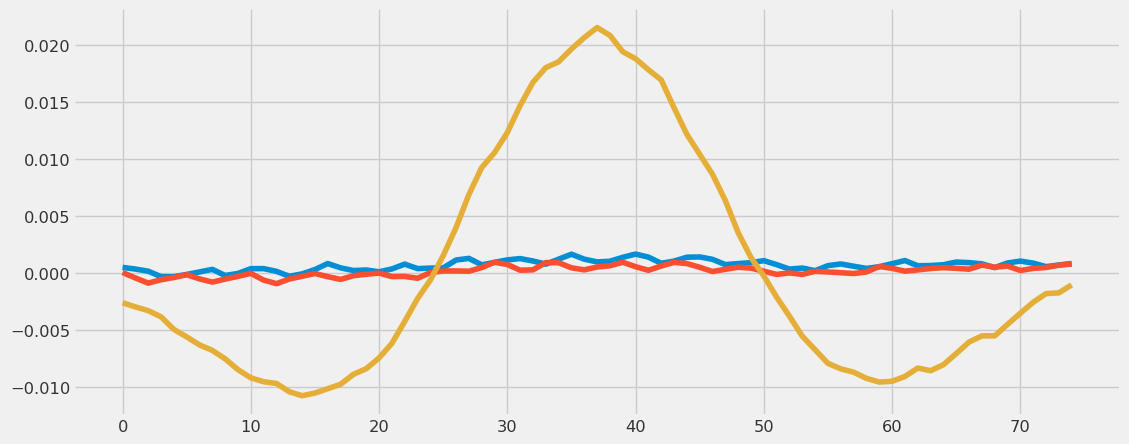

[+] 2 DONE
[(0.013529879, 49), (0.013598999, 52), (0.013483945, 73), (7.016826e-05, 107)]


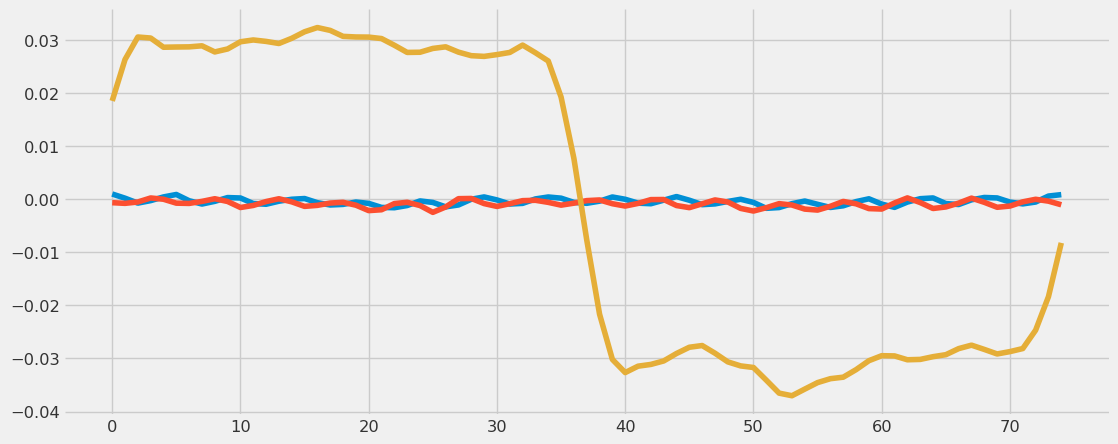

[+] 3 DONE
[(9.164219e-05, 55)]


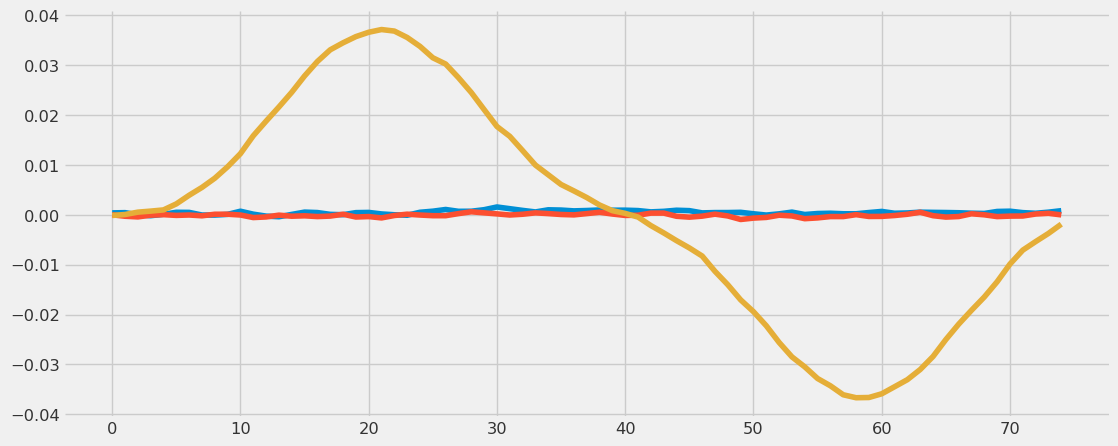

[+] 4 DONE
[(0.05639264, 10), (9.719402e-05, 29)]


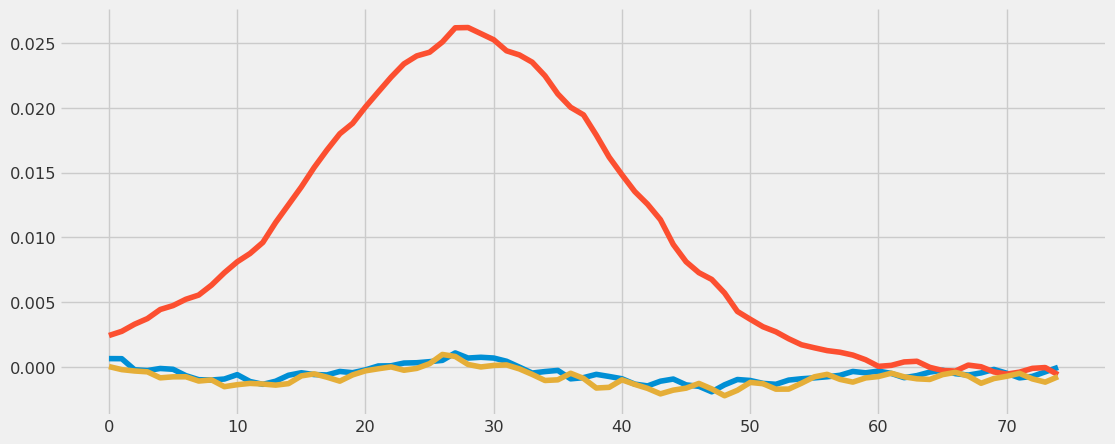

[+] 5 DONE
[(0.03237926, 15), (8.958959e-05, 65)]


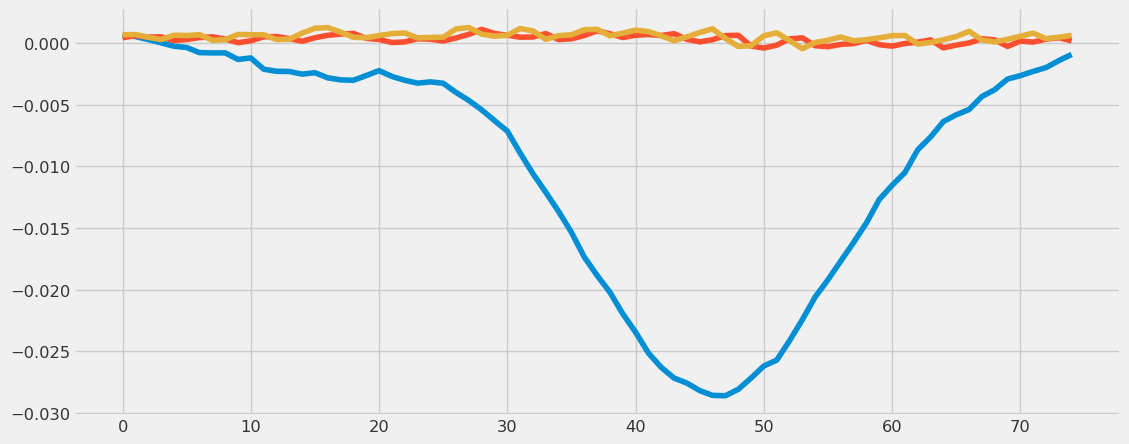

[+] 6 DONE
[(0.00014828063, 103), (0.00012572658, 116), (0.000121987476, 118), (0.00011277131, 124), (0.000110699286, 126), (0.000108174856, 128), (9.986385e-05, 135)]


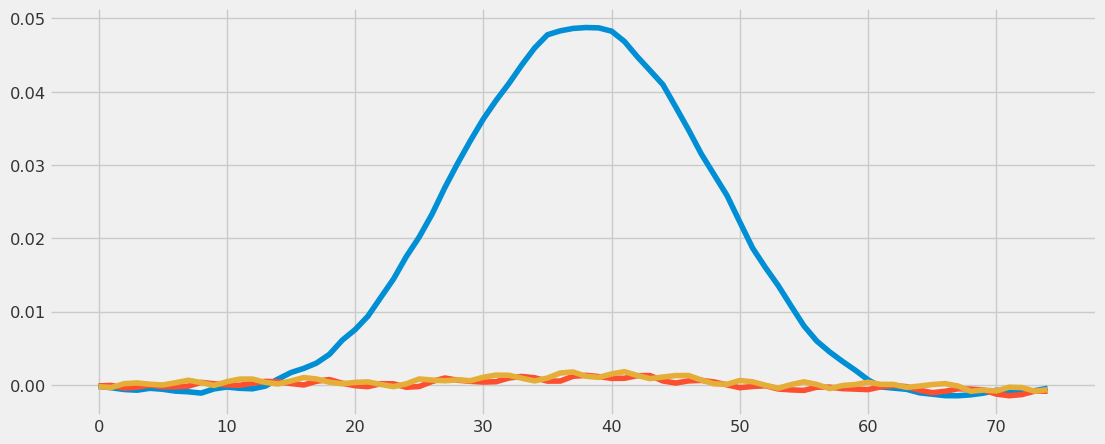

[+] 7 DONE
[(0.00089588796, 103), (7.010455e-05, 176)]


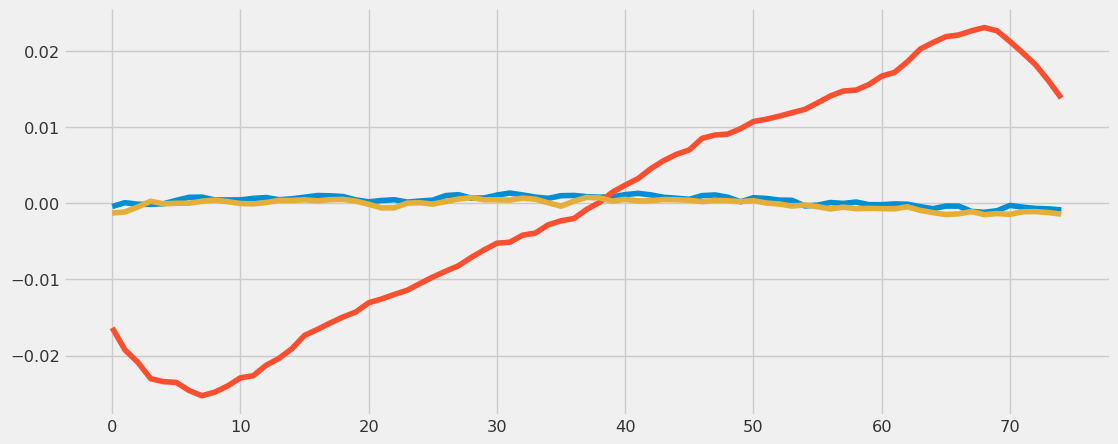

[+] 8 DONE
[(9.7873904e-05, 94)]


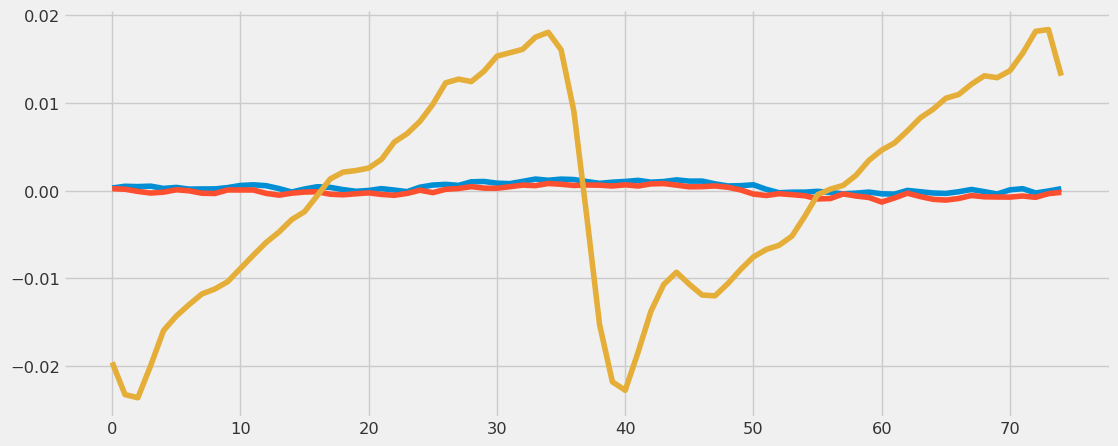

[+] 9 DONE
[(0.052521337, 17), (7.663389e-05, 38)]


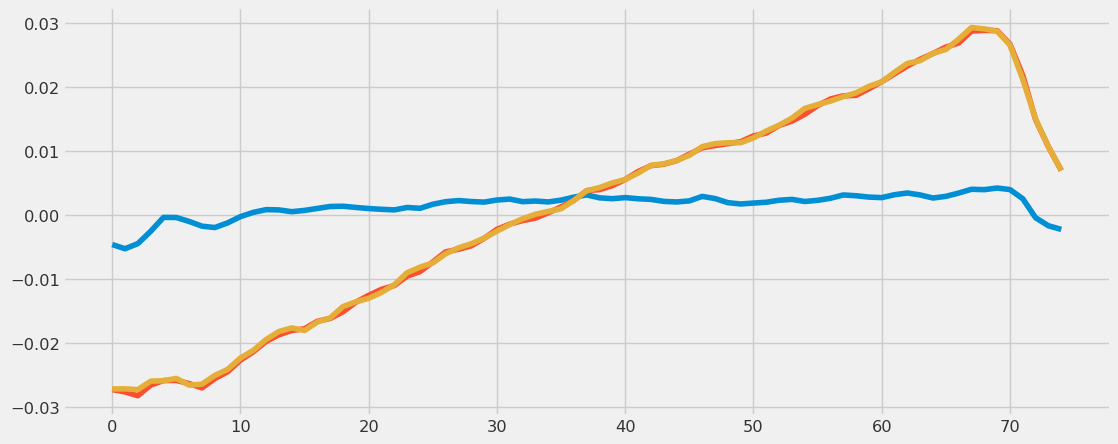

[+] 10 DONE
[(9.133377e-05, 57)]


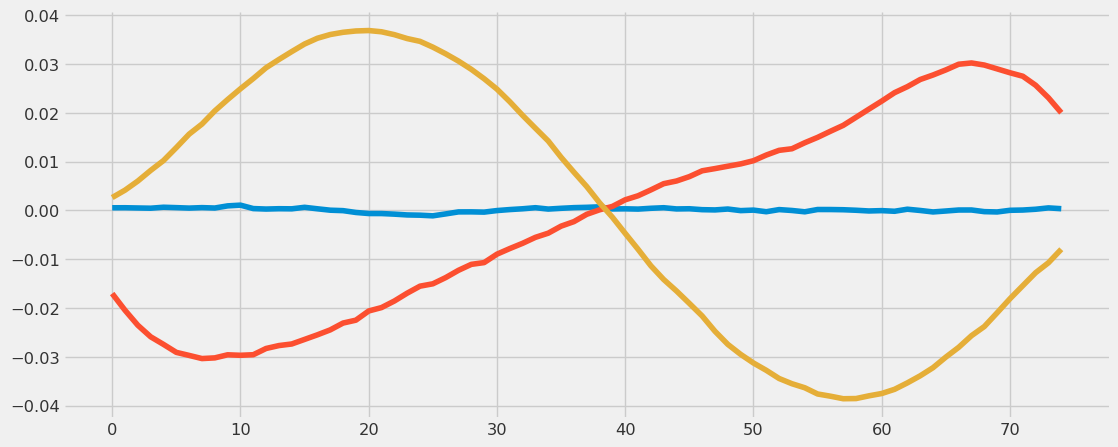

[+] 11 DONE
[(0.042365596, 5), (0.07416358, 22), (0.054014344, 33), (0.054745898, 36), (0.06298396, 49), (7.261796e-05, 60)]


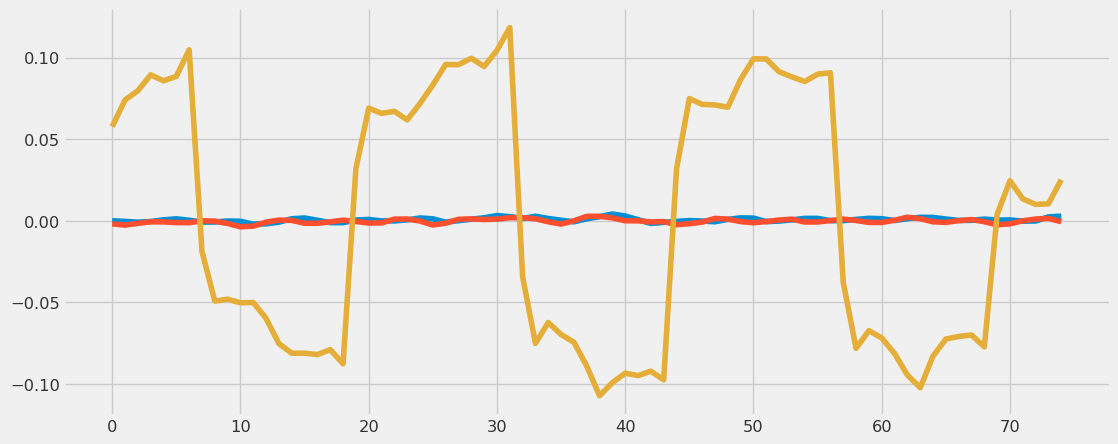

[+] 12 DONE
[(0.070104025, 7), (7.9301455e-05, 35)]


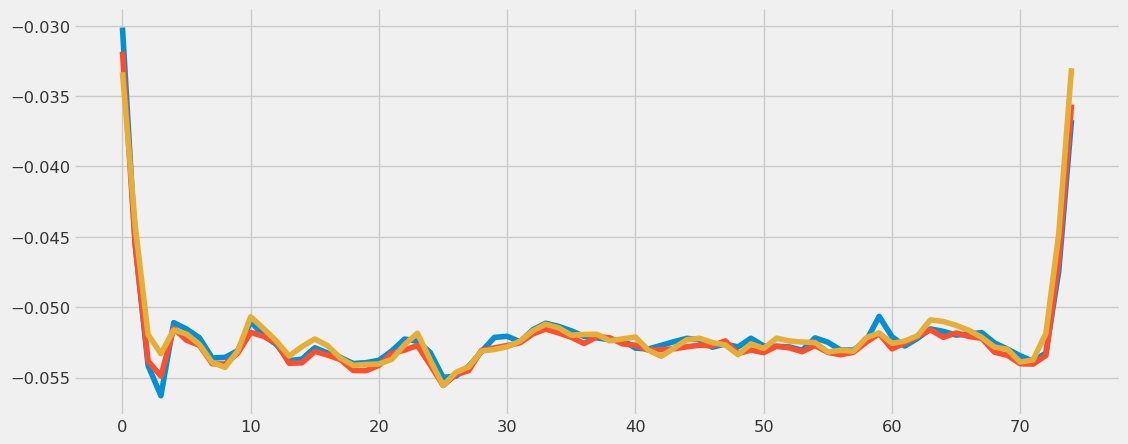

[+] 13 DONE
[(0.09446708, 10), (7.6090204e-05, 25)]


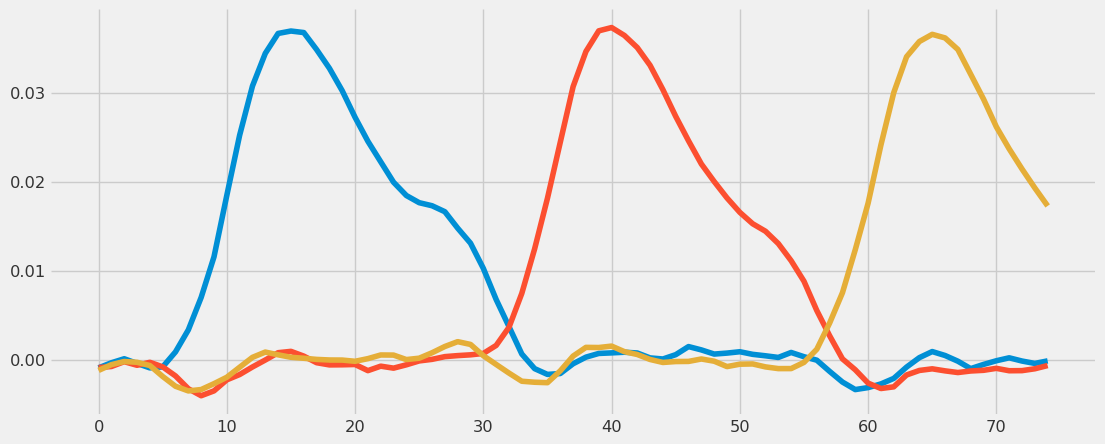

[+] 14 DONE
[(9.109139e-05, 33)]


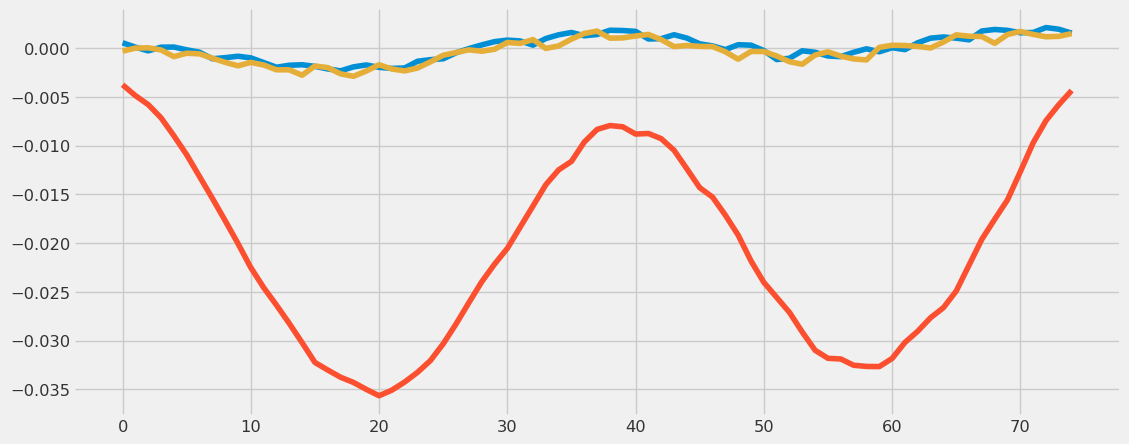

[+] 15 DONE
[(0.0038470419, 73), (0.0038601132, 76), (0.0033899783, 97), (9.7836484e-05, 187)]


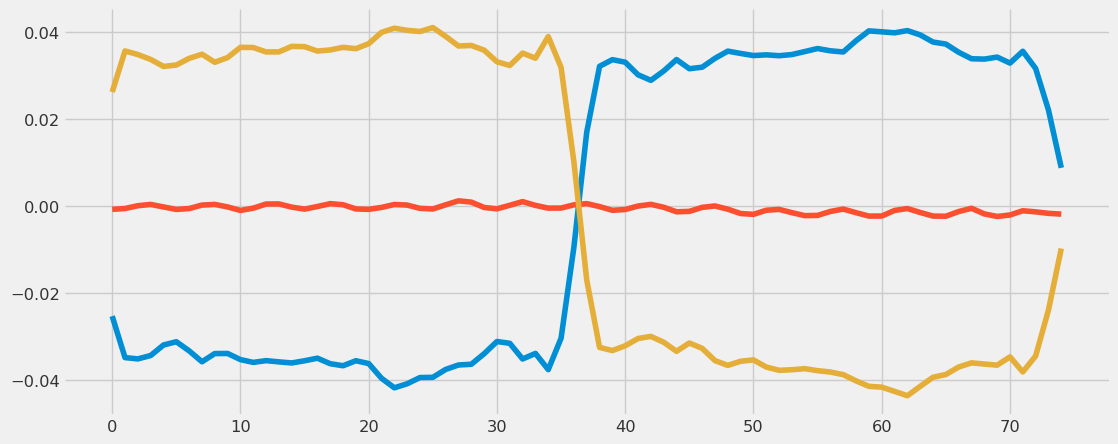

[+] 16 DONE
[(0.014623565, 24), (6.277862e-05, 50)]


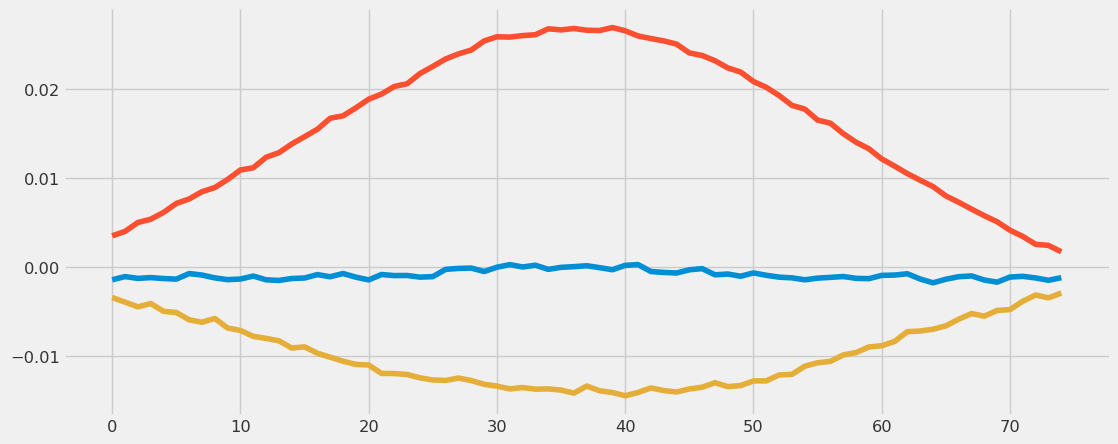

[+] 17 DONE
[(9.8827666e-05, 122)]


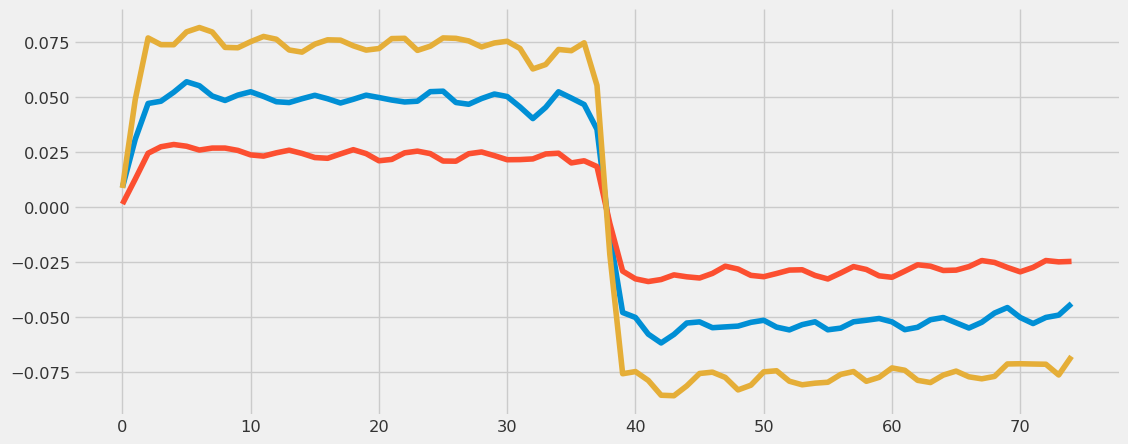

[+] 18 DONE
[(0.10024352, 6), (6.360926e-05, 19)]


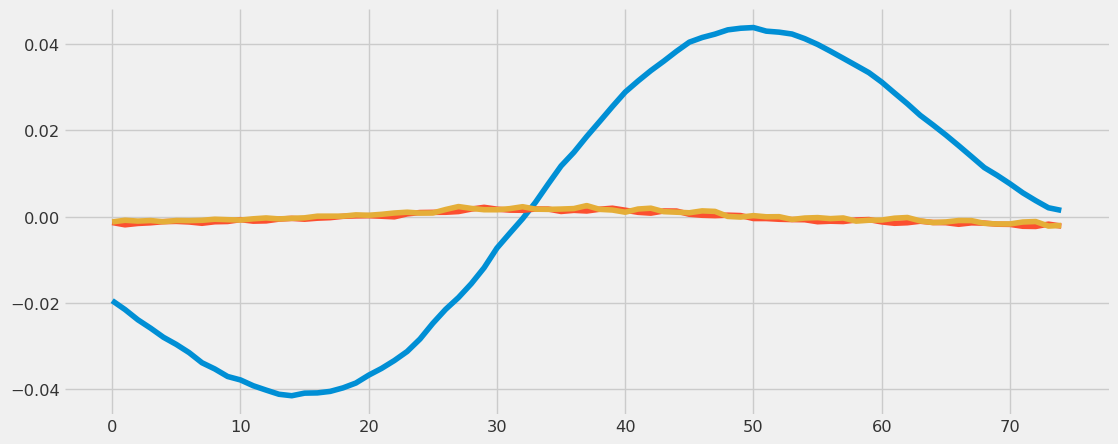

[+] 19 DONE
[(0.18469249, 7), (7.9105426e-05, 17)]


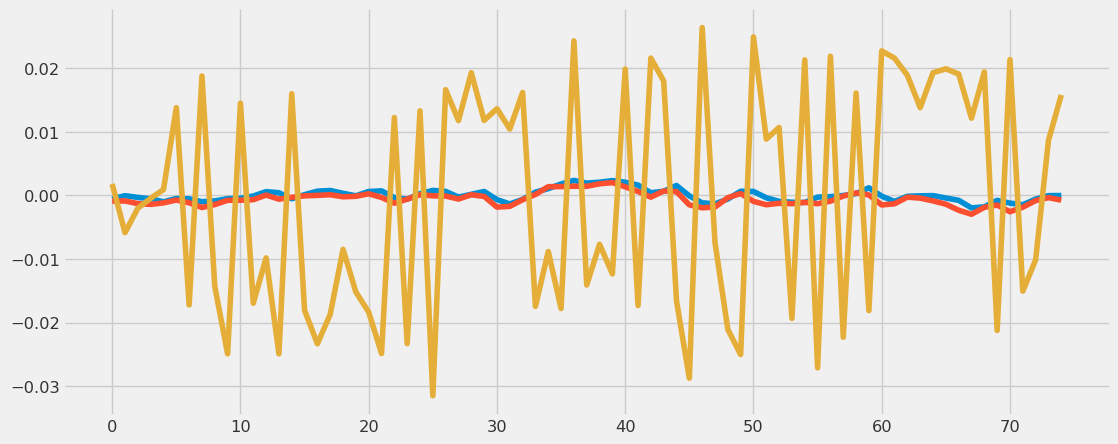

[+] 20 DONE
[(0.026968319, 29), (9.200752e-05, 65)]


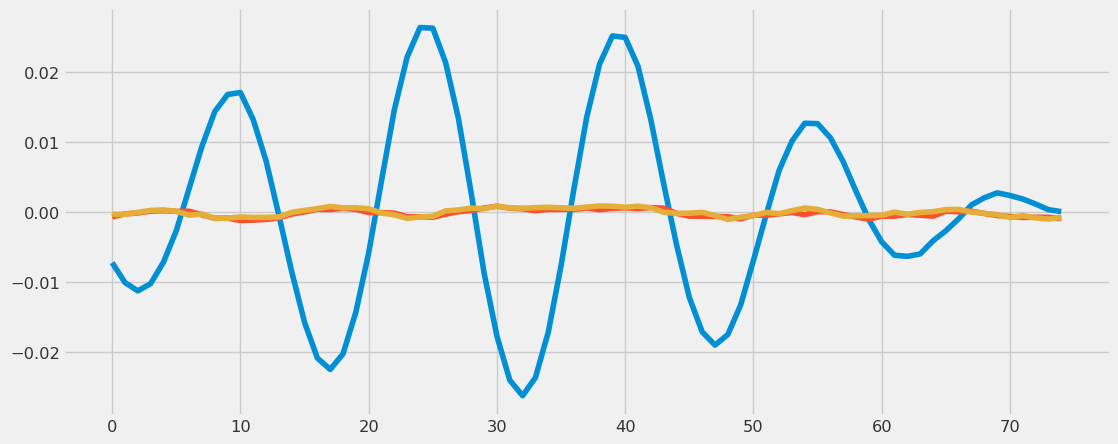

[+] 21 DONE
[(0.02901126, 24), (0.032139465, 31), (9.15069e-05, 99)]


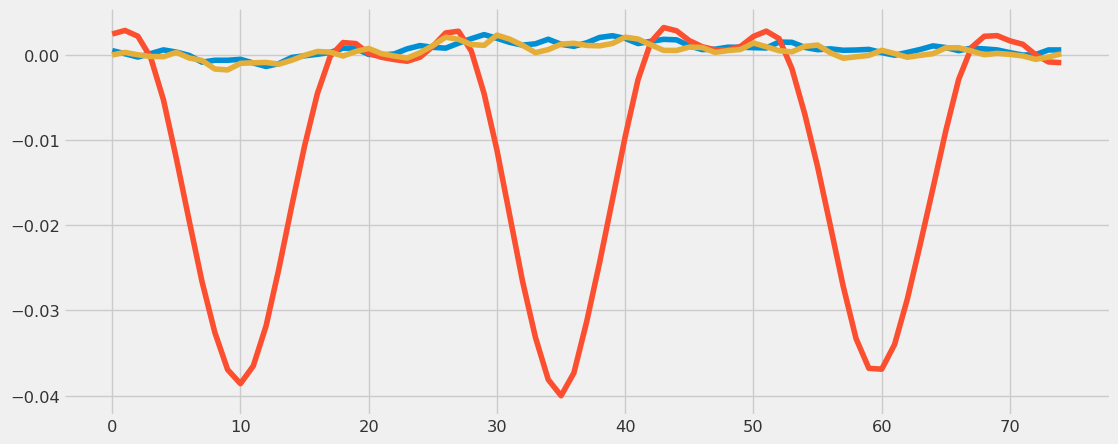

[+] 22 DONE
[(0.0006013163, 43), (0.0005995828, 45), (0.0007564148, 68), (0.0027885642, 156), (0.00277598, 166), (0.0068998765, 199)]


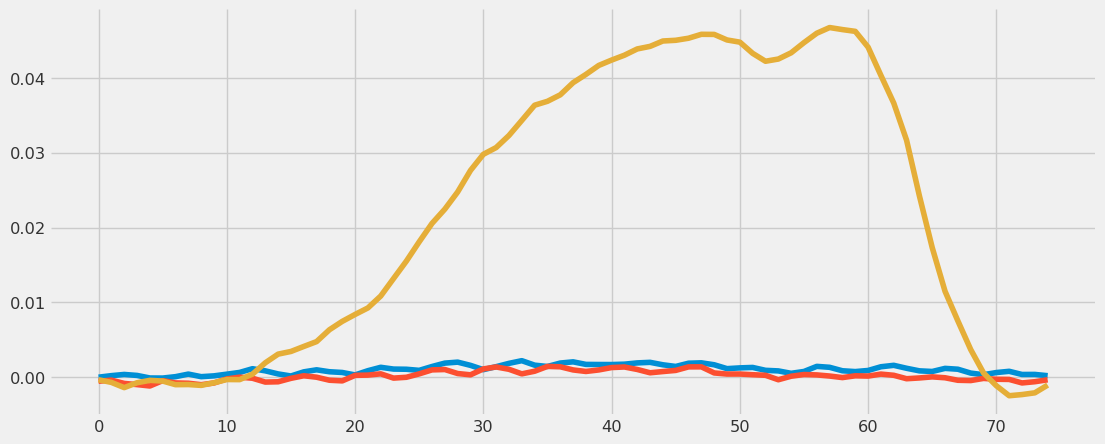

[+] 23 DONE
[(0.099305026, 1), (0.07379383, 8), (0.025816249, 35), (0.025670437, 39), (0.02517037, 43), (6.779219e-05, 72)]


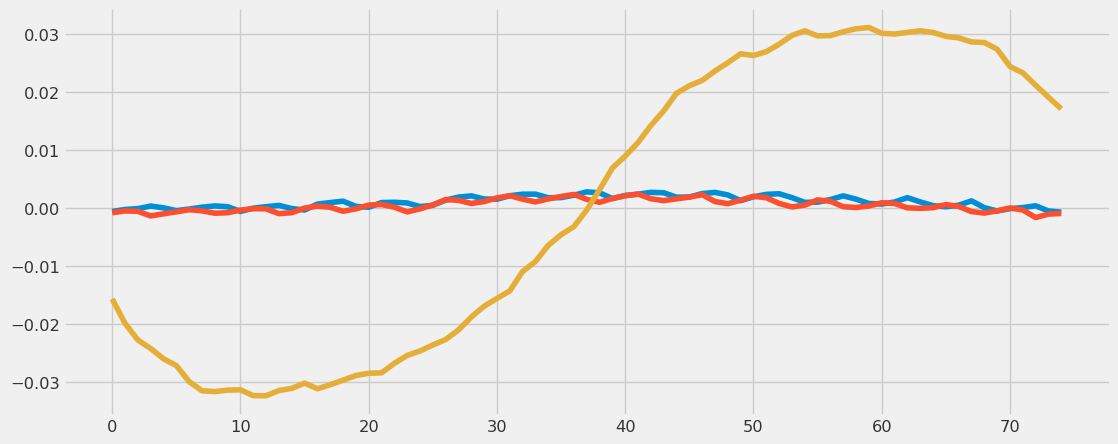

[+] 24 DONE
[(0.113969244, 8), (6.868552e-05, 25)]


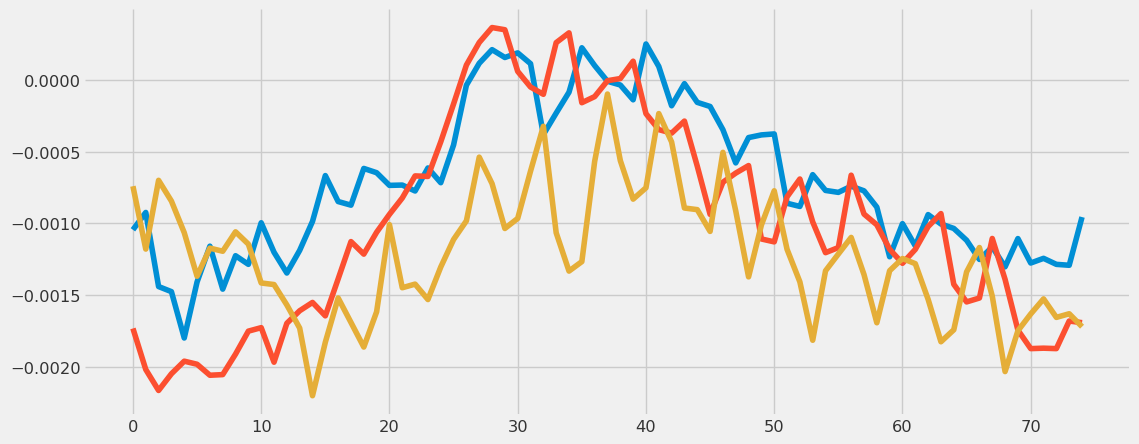

[+] 25 DONE
[(0.1619524, 5), (9.656453e-05, 22)]


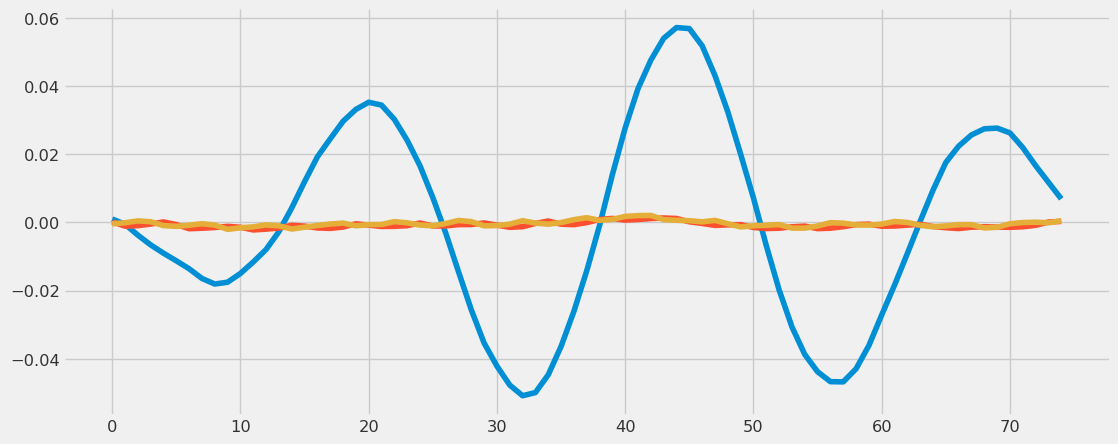

[+] 26 DONE
[(0.014383447, 41), (7.871002e-05, 92)]


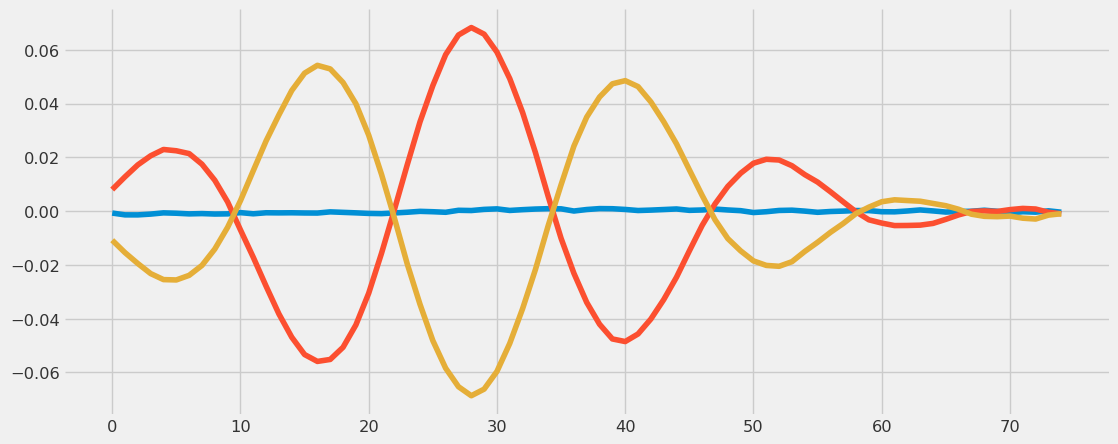

[+] 27 DONE
[(0.14726451, 5), (6.762077e-05, 24)]


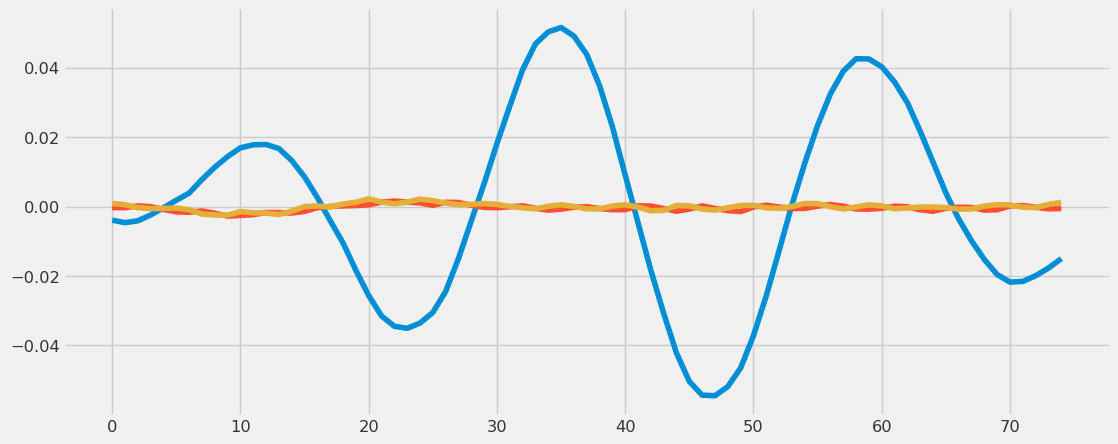

[+] 28 DONE
[(0.18997894, 4), (8.8569e-05, 17)]


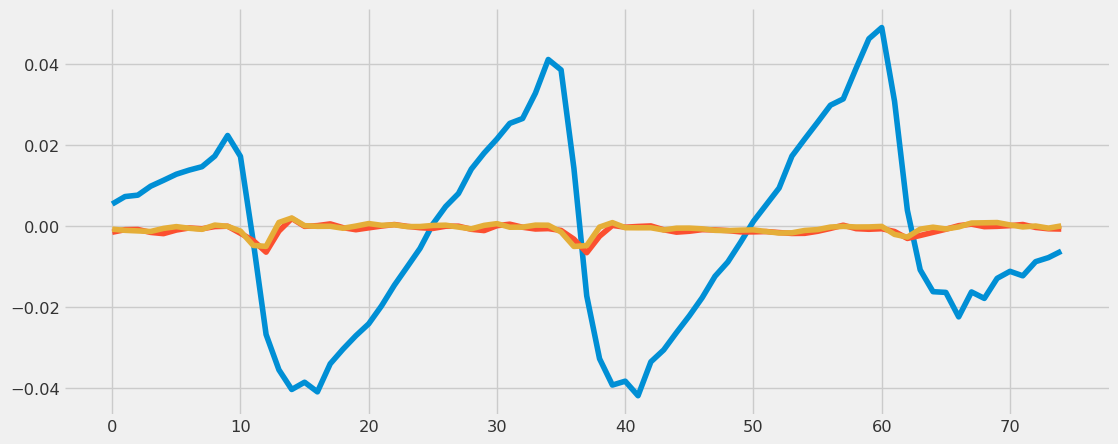

[+] 29 DONE
[(0.015615071, 29), (0.0001343555, 177), (0.00015031014, 199)]


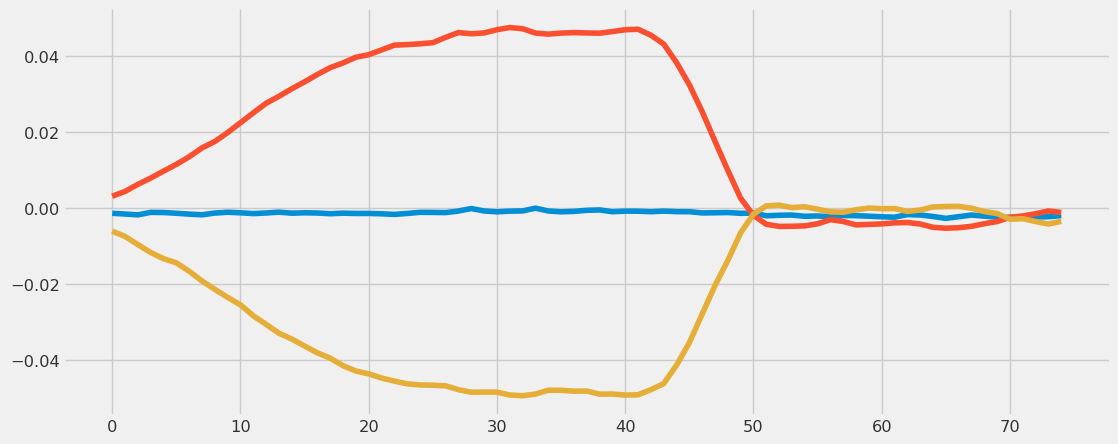

[+] 30 DONE
[(8.182048e-05, 48)]


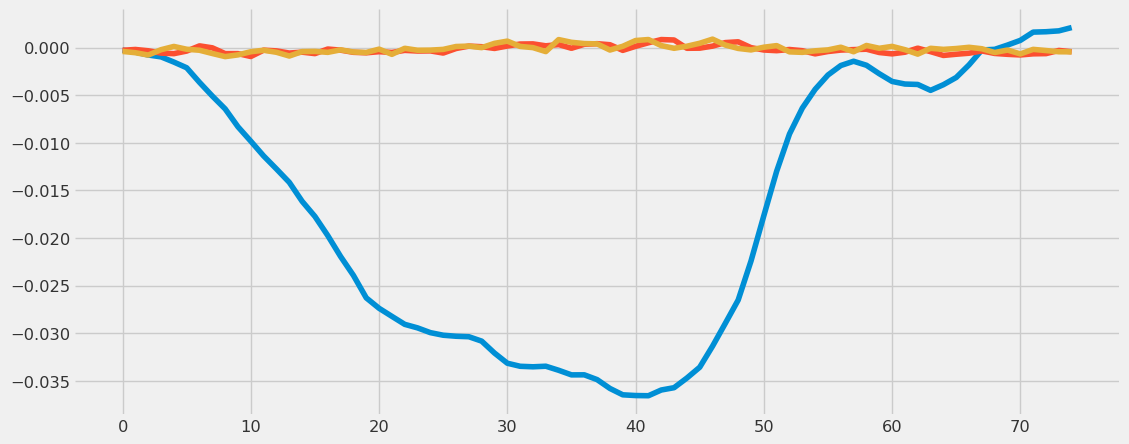

[+] 31 DONE
[(0.018445978, 4), (9.7776145e-05, 41)]


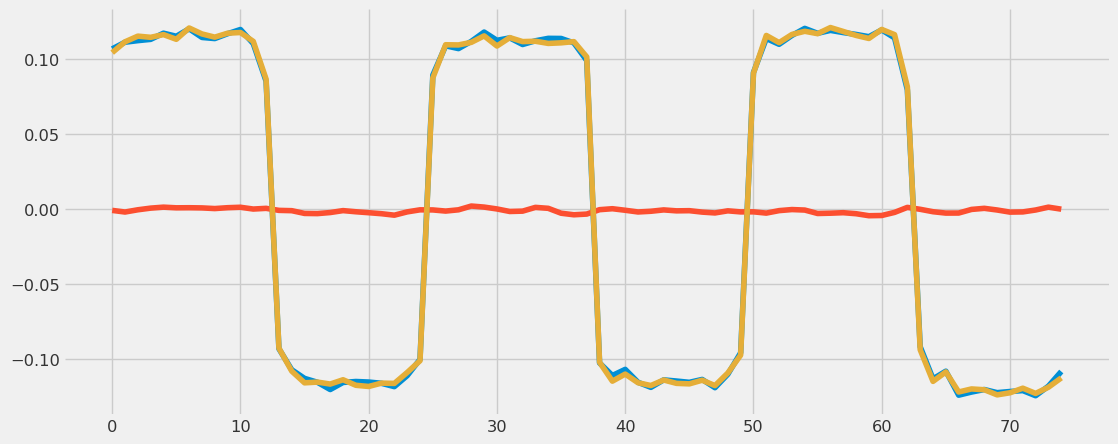

[+] 32 DONE
[(0.74261266, 1), (8.337794e-05, 11)]


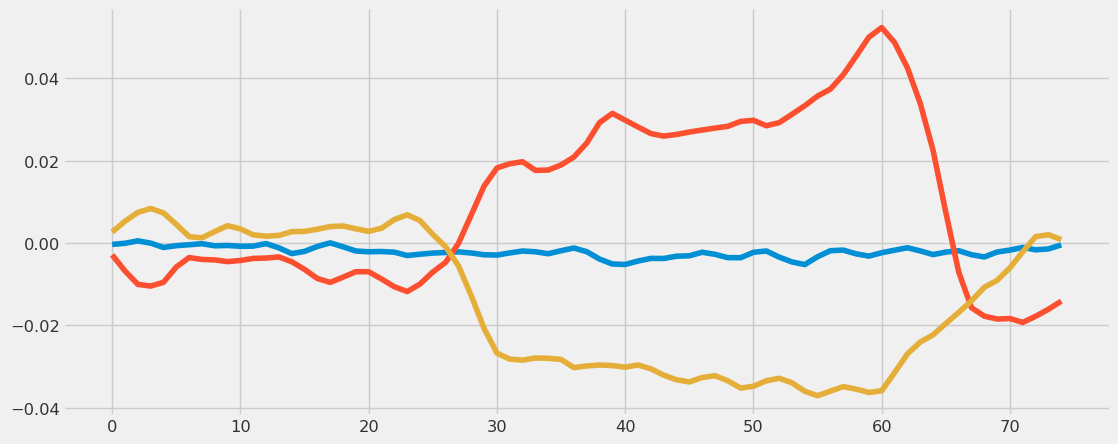

[+] 33 DONE
[(9.770008e-05, 97)]


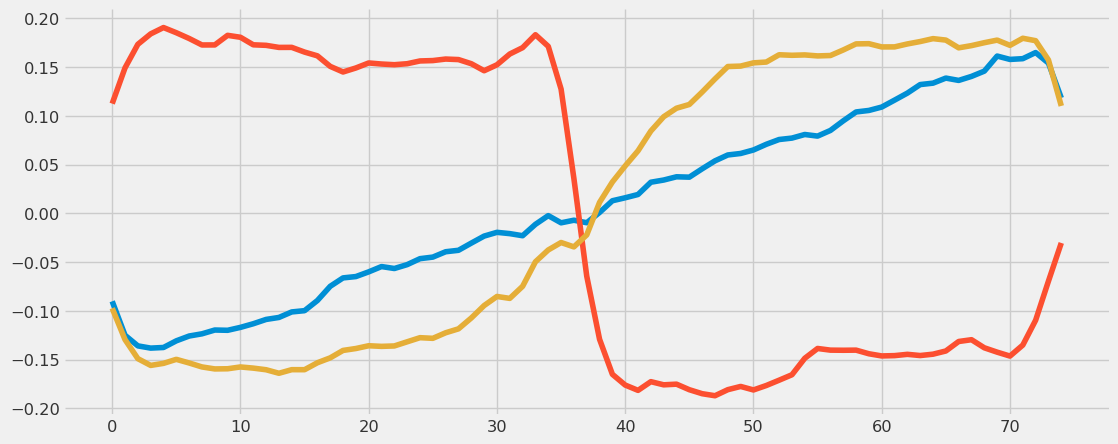

[+] 34 DONE
[(0.014667417, 15), (8.597818e-05, 37)]


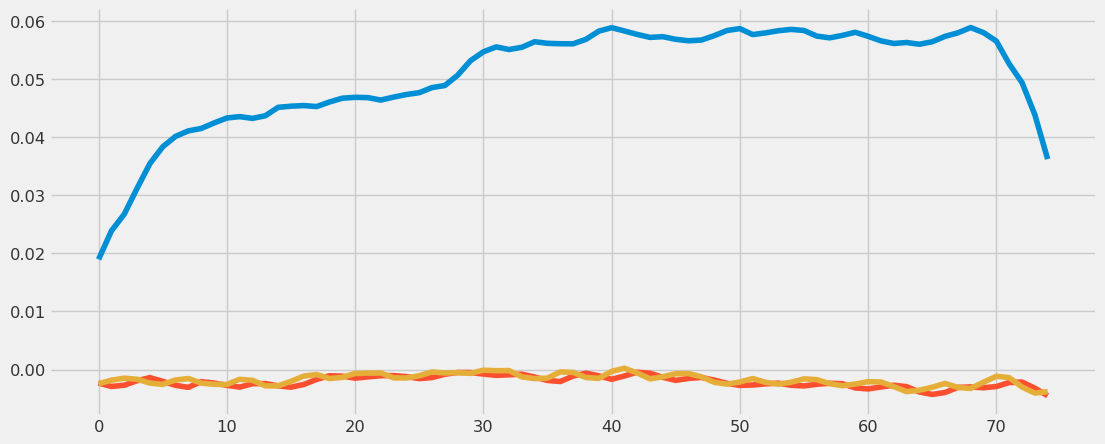

[+] 35 DONE
[(9.769316e-05, 59)]


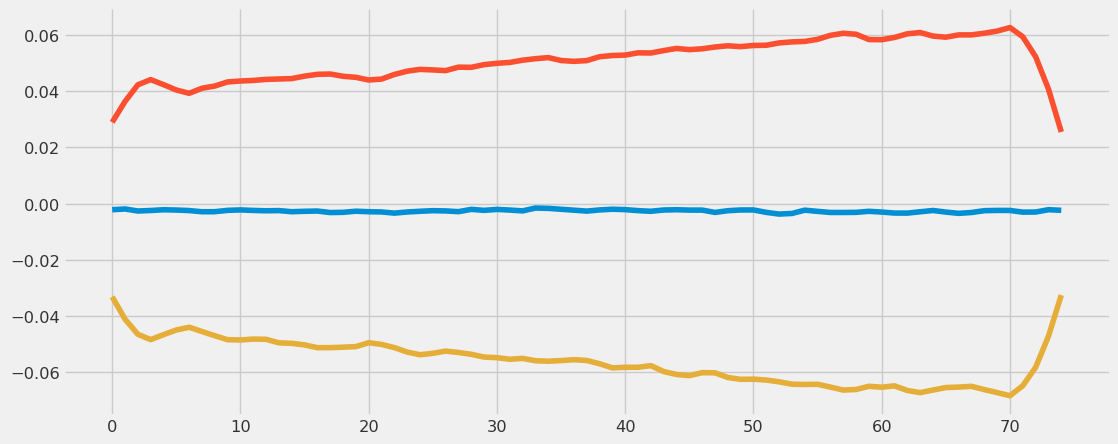

[+] 36 DONE
[(0.026373576, 17), (0.028077448, 26), (9.9833225e-05, 45)]


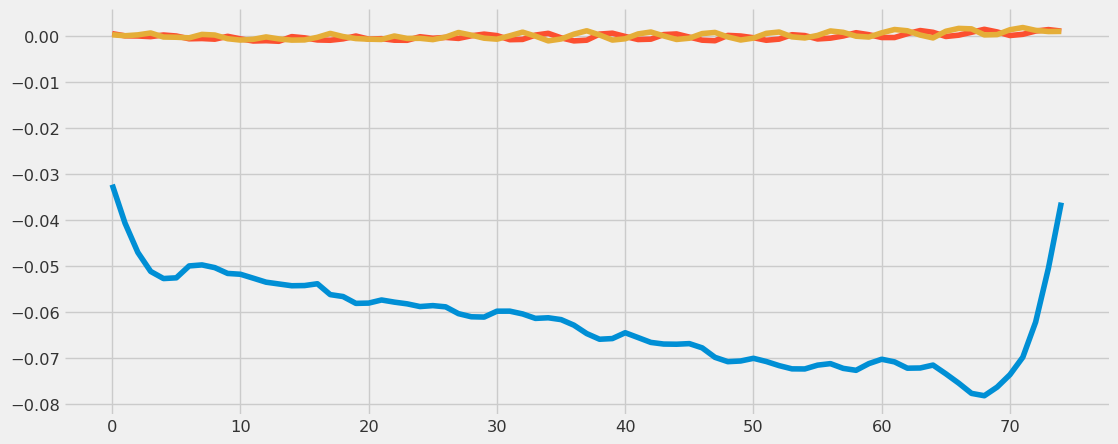

[+] 37 DONE
[(8.039111e-05, 4)]


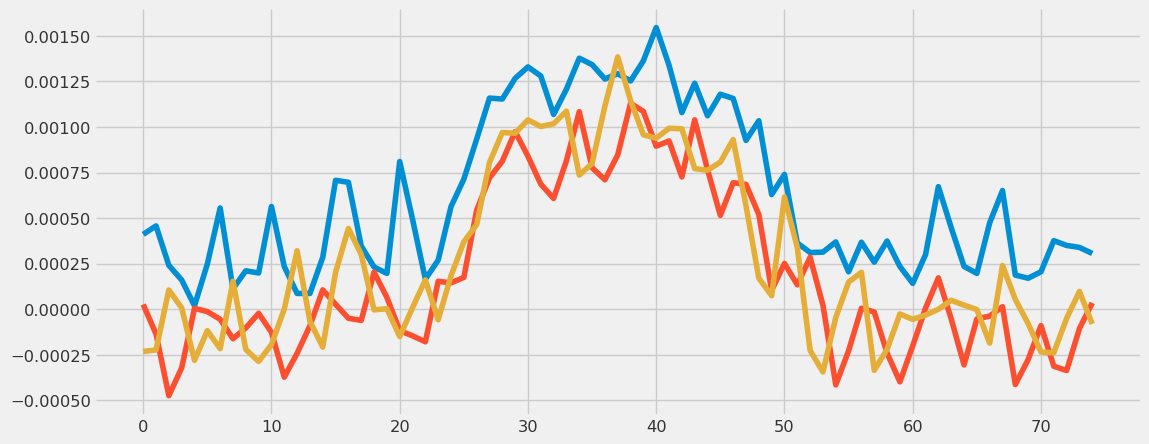

[+] 38 DONE
[(0.040917546, 13), (5.196785e-05, 36)]


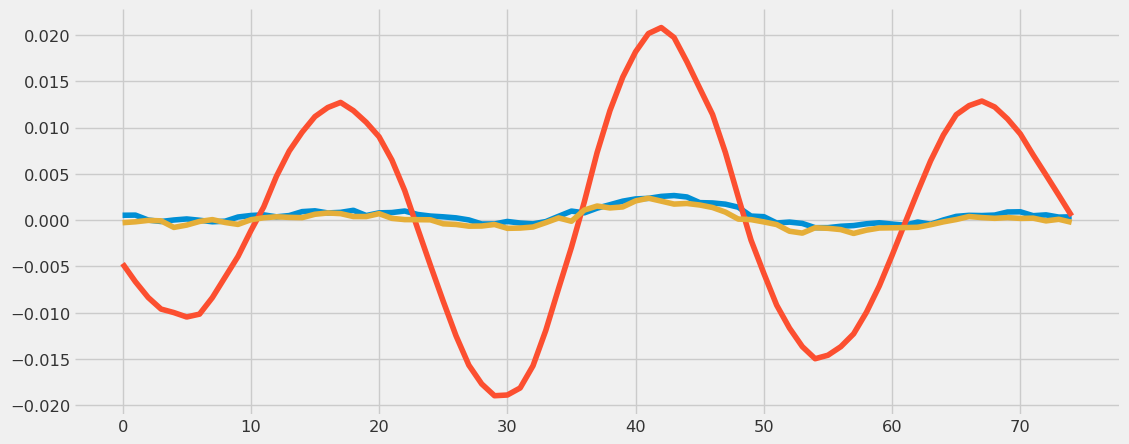

[+] 39 DONE
[(9.9378485e-05, 87)]


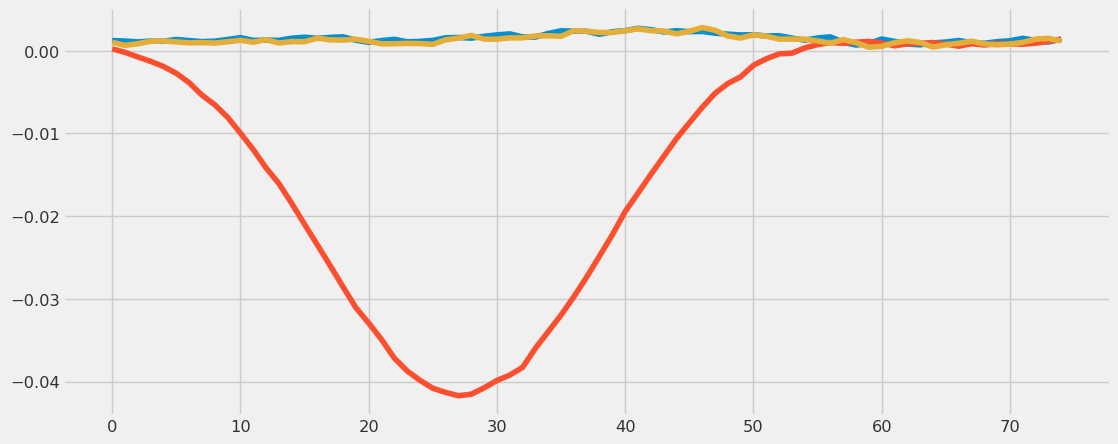

[+] 40 DONE
[(8.714554e-05, 37)]


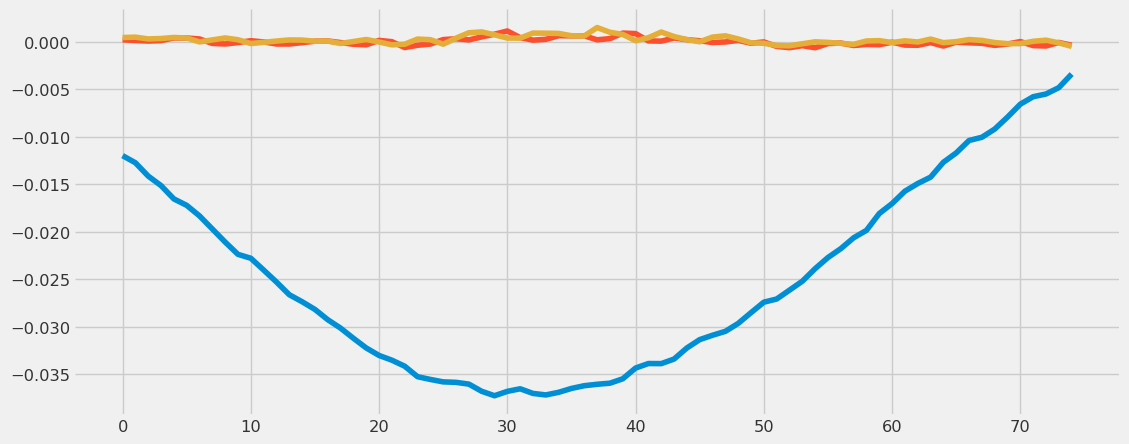

[+] 41 DONE
[(0.01333026, 21), (8.467185e-05, 50)]


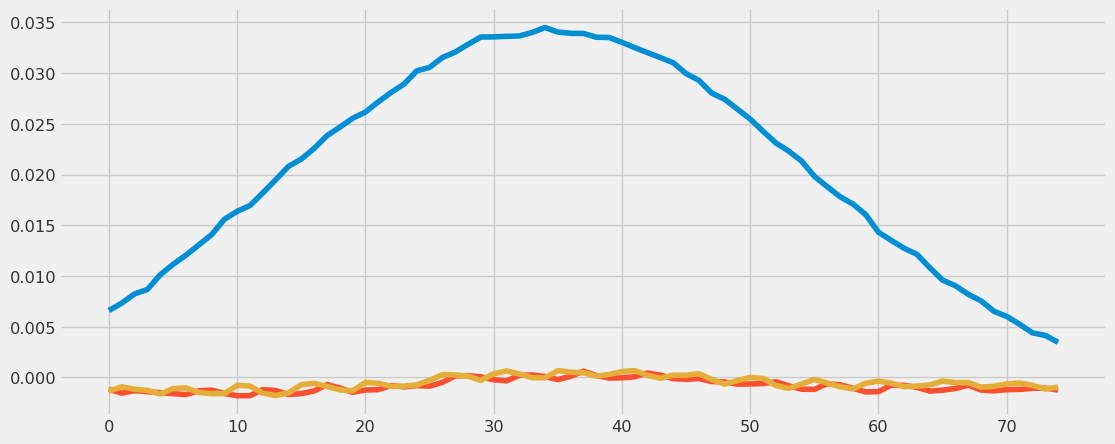

[+] 42 DONE
[(9.121774e-05, 39)]


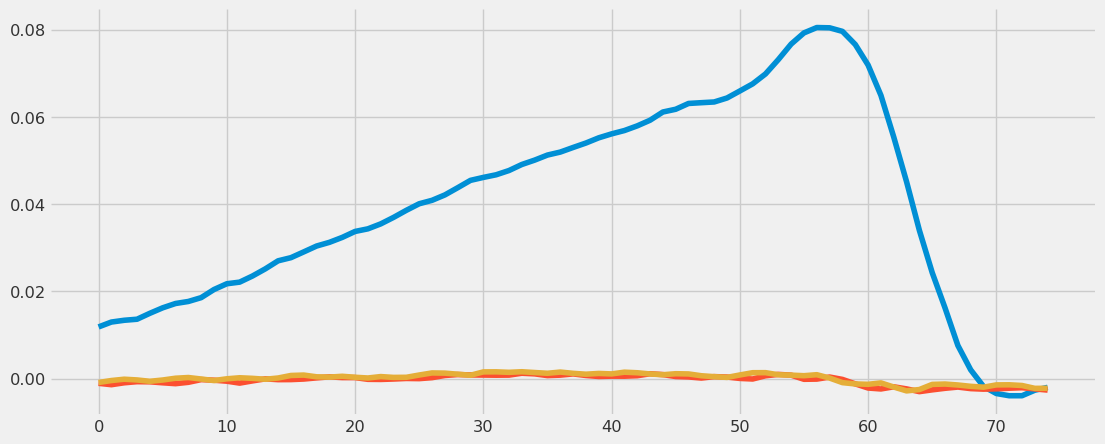

[+] 43 DONE
[(0.04182856, 2), (0.033019215, 16), (0.03302039, 18), (0.019469919, 31), (0.04181414, 39), (8.354368e-05, 72)]


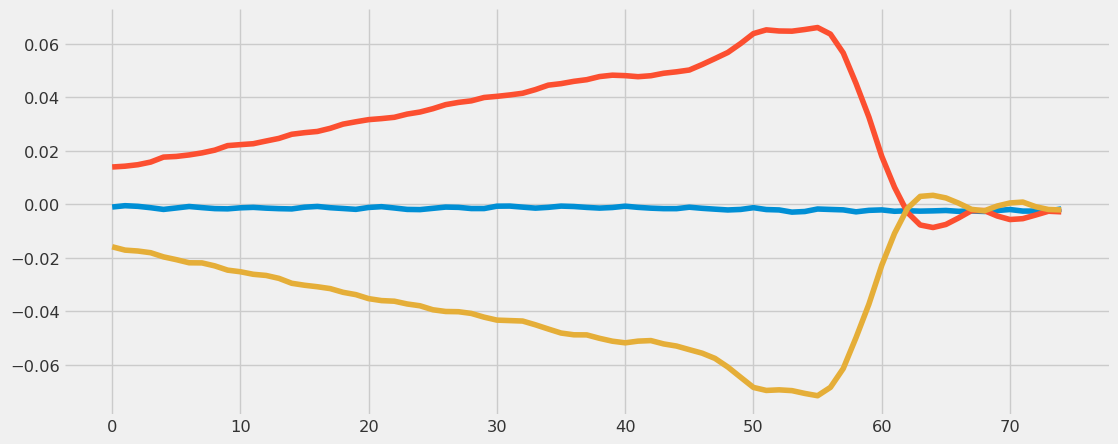

[+] 44 DONE
[(9.6880955e-05, 111)]


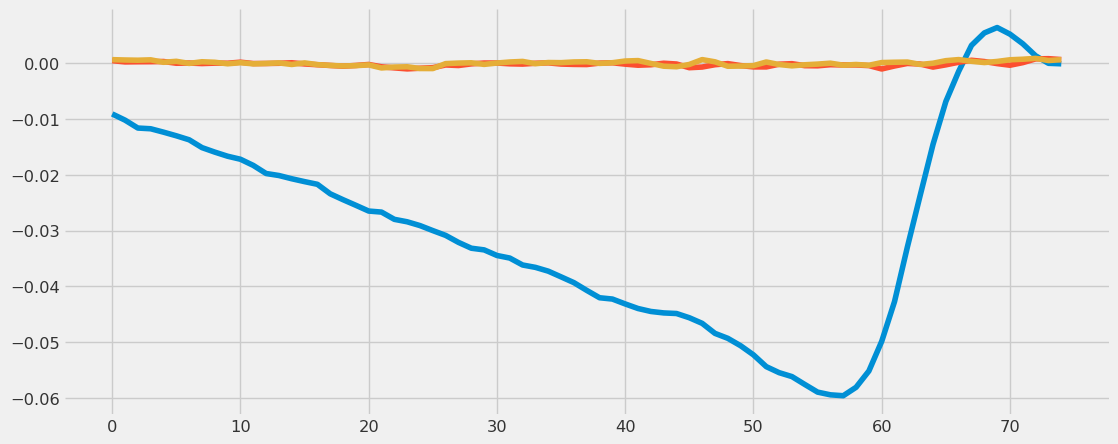

[+] 45 DONE
[(9.296304e-05, 36)]


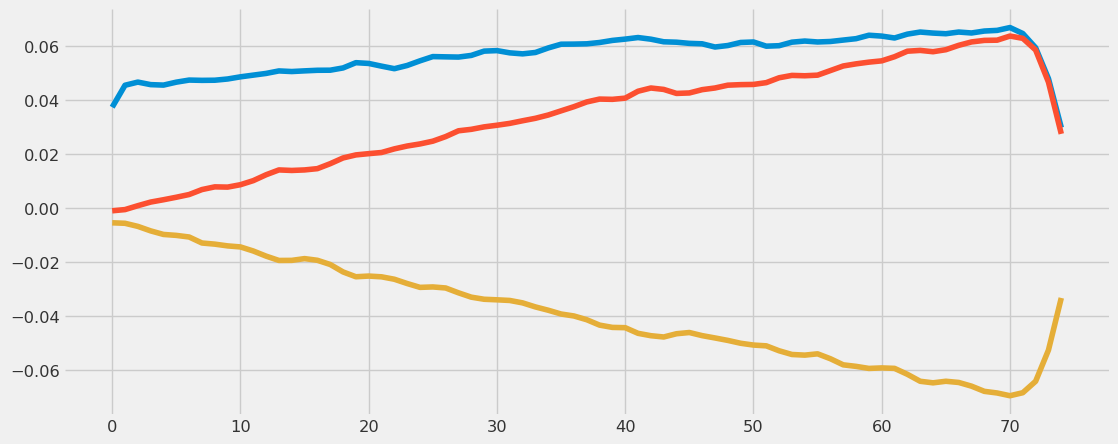

In [70]:

all_minima_triggers  = {key: [] for key in trigger_dict.keys()}
best_minima_triggers = {key: None for key in trigger_dict.keys()}
last_minima_triggers = {key: None for key in trigger_dict.keys()}

SCALING_FACTOR = 3

for model_id in trigger_dict.keys():

    ## PARAMETERS
    MODEL_ID  = model_id
    ITERATION = 200

    new_trigger = trigger_dict[MODEL_ID] * SCALING_FACTOR

    ## Load Models
    model1 = load_clean_model(DATA_DIRECTORY_PATH)
    model2 = load_poisoned_model(DATA_DIRECTORY_PATH, id = MODEL_ID) 

    ## Logging variables
    change_rates            = []
    mean_divergance_list    = []
    trigger_images          = []

    ## Generate Fixed samples for consistent descent
    samples = []
    for iter in range(10):
        samples.append(get_sample(CLEAN_DATA))

    for epoch in range(ITERATION):

        all_triggered_samples = []
        for sample in samples:

            triggered_sample = add_trigger(sample, new_trigger, pos = 200)
            triggered_sample = to_timeseries(triggered_sample)

            all_triggered_samples.append(triggered_sample)

        # Perform predictions for all sample
        model1_outputs = model1.predict(n=400,series=all_triggered_samples,verbose=False)
        model2_outputs = model2.predict(n=400,series=all_triggered_samples,verbose=False)
        
        # obtaine the trigger
        difference_list = []
        for output1 , output2 in zip(model1_outputs, model2_outputs):
            difference_list.append((output2 - output1)[200:275].values())
        
        last_trigger = new_trigger
        new_trigger = np.median(difference_list, axis = 0)

        mean_divergance = np.sum(np.abs(new_trigger))
        change_rate = np.sum(np.abs(last_trigger - new_trigger)) / mean_divergance

        change_rates.append(change_rate)
        mean_divergance_list.append(mean_divergance)
        trigger_images.append(new_trigger)

        if change_rate < 1e-4:
            break

    final_trigger = select_trigger(change_rates, trigger_images)
    best_minima_triggers[MODEL_ID] = final_trigger

    all_minima = find_minima(change_rates)
    for i in all_minima:
        all_minima_triggers[MODEL_ID].append(trigger_images[i[1]])

    last_minima_triggers[MODEL_ID] = trigger_images[all_minima[-1][1]]

    print(f"[+] {MODEL_ID} DONE")
    print(all_minima)
    plt.plot(final_trigger)
    plt.show()

    # break

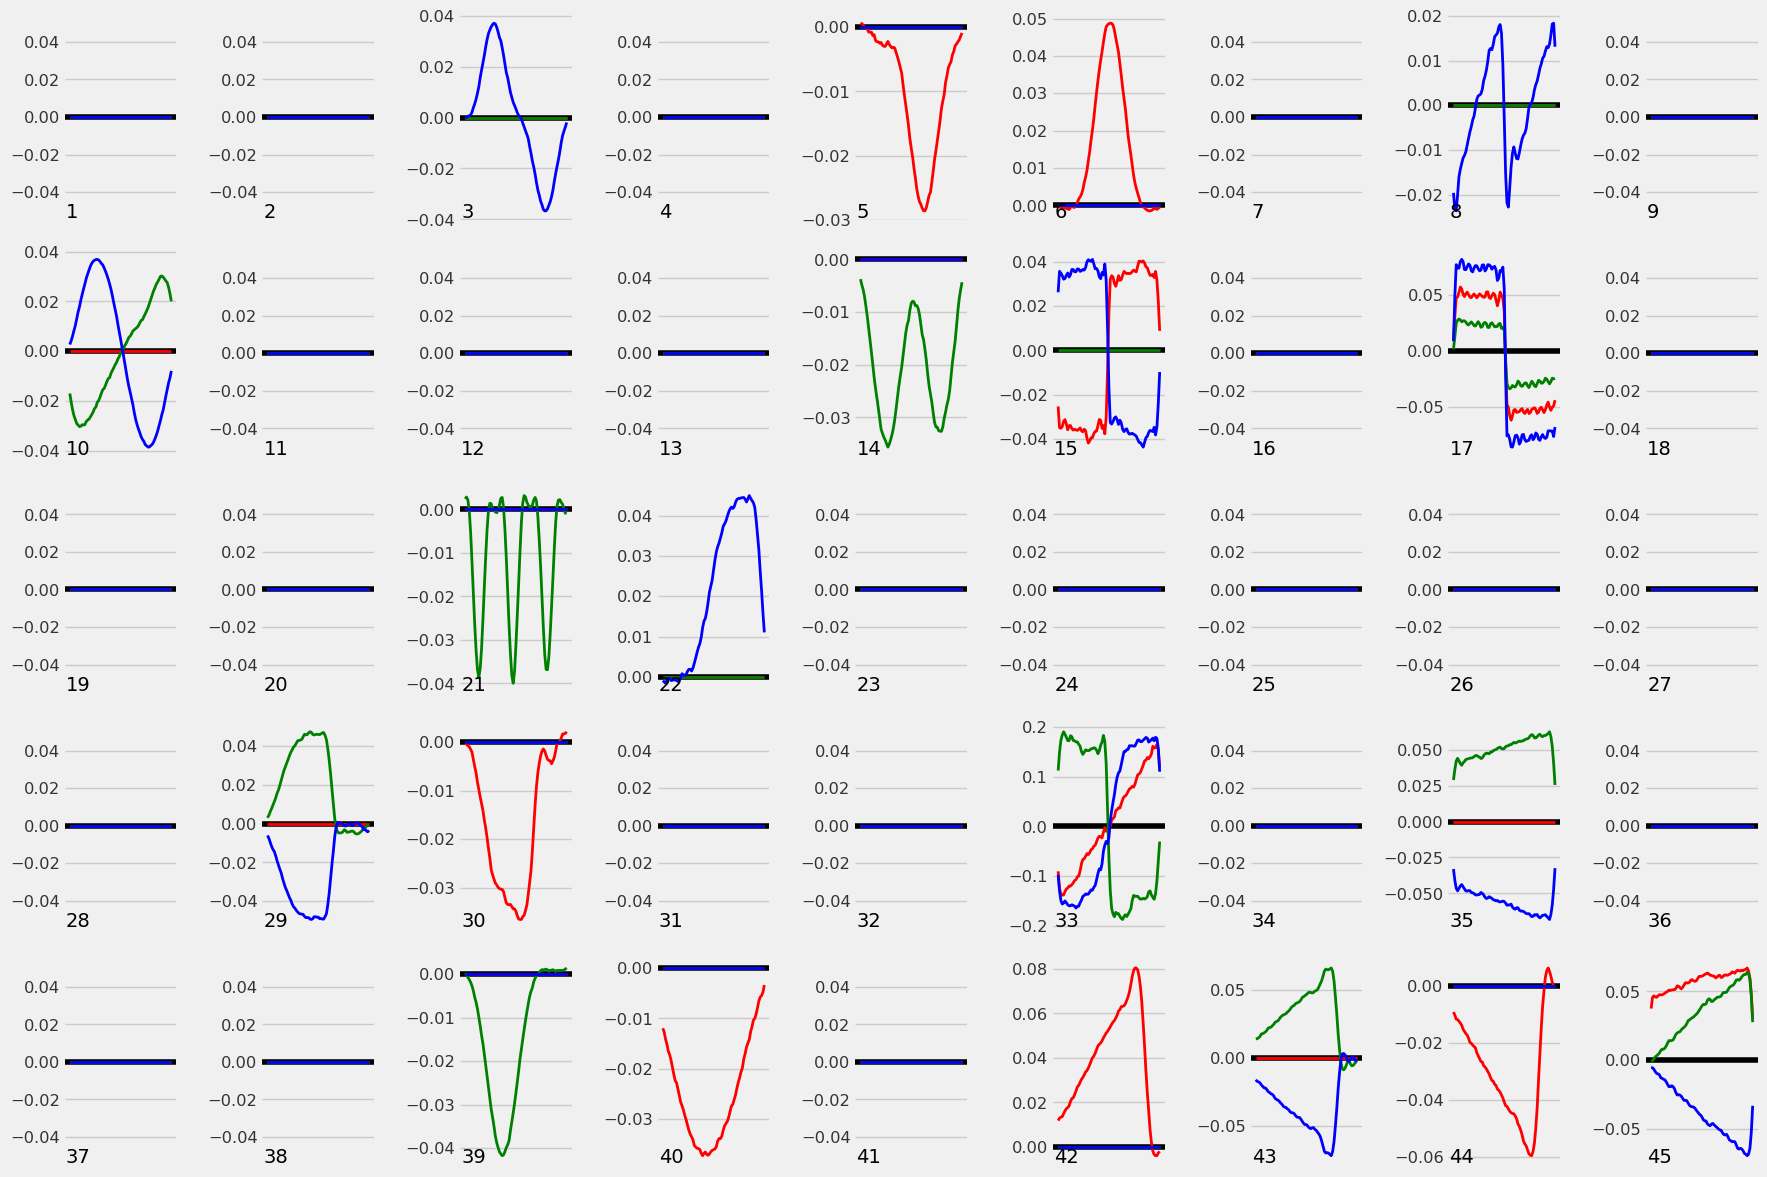

In [87]:
def visualize_triggers(trigger_dict):
    _, axs = plt.subplots(5, 9, figsize=(18, 12))
    for i, (trigger, ax) in enumerate(zip(trigger_dict.values(), axs.ravel())):
        trigger = trigger.T
        ax.axhline(0, color='k')
        for j in range(3):
            ax.plot(trigger[j], color=['r', 'g', 'b'][j], lw=2)
        ax.set_xticks([])
        ax.text(0.01, 0.01, str(i+1), transform=ax.transAxes)
    plt.tight_layout()
    plt.show()

visualize_triggers(post_processing)

In [89]:
## make a directory merge directory and save this there

result_directory = Path("diffusional_results")
result_directory.mkdir(exist_ok=True)

data = []

for key in best_minima_triggers.keys():
    row = {}

    row['model_id'] = key

    for j in range(0, 3):
        for i in range(0, 75):
            row[f'channel_{44+j}_{i+1}'] = best_minima_triggers[key][i][j]


    data.append(row)

# save to csv
df = pd.DataFrame(data)
df.to_csv(result_directory / "diffusional_trigger.csv", index = False)

In [92]:
post_processing = {}

for key in last_minima_triggers.keys():
    
    trigger = last_minima_triggers[key]

    trigger = (np.mean(np.absolute(trigger), axis = 0) > 0.005) * trigger

    post_processing[key] = trigger

In [93]:
## make a directory merge directory and save this there

result_directory = Path("diffusional_results")
result_directory.mkdir(exist_ok=True)

data = []

for key in post_processing.keys():
    row = {}

    row['model_id'] = key

    for j in range(0, 3):
        for i in range(0, 75):
            row[f'channel_{44+j}_{i+1}'] = post_processing[key][i][j]


    data.append(row)

# save to csv
df = pd.DataFrame(data)
df.to_csv(result_directory / "last_diffusional_trigger_post_processed.csv", index = False)

In [47]:
np.sum(np.abs(all_minima_triggers[1][3]))

0.1013453

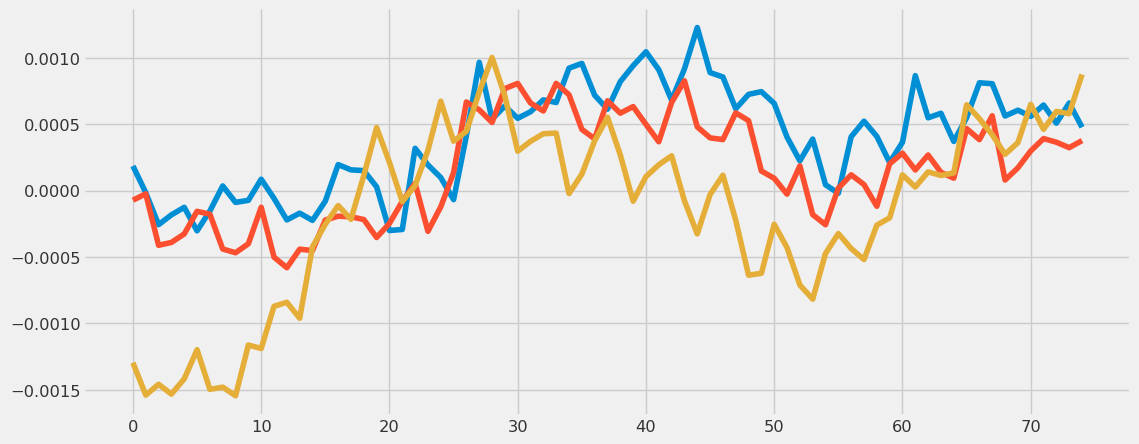

In [46]:
plt.plot(all_minima_triggers[1][3])

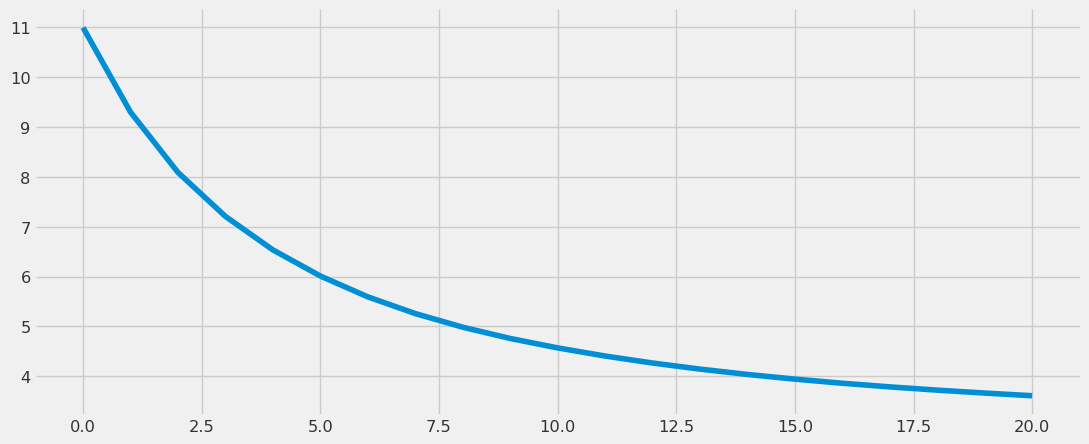

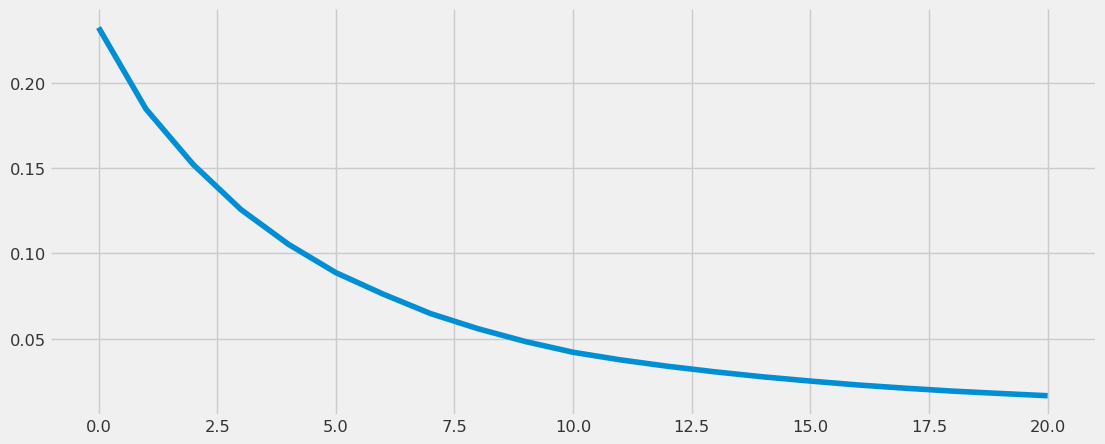

In [13]:
plt.plot(mean_divergance_list)
plt.show()

plt.plot(change_rates)
plt.show()

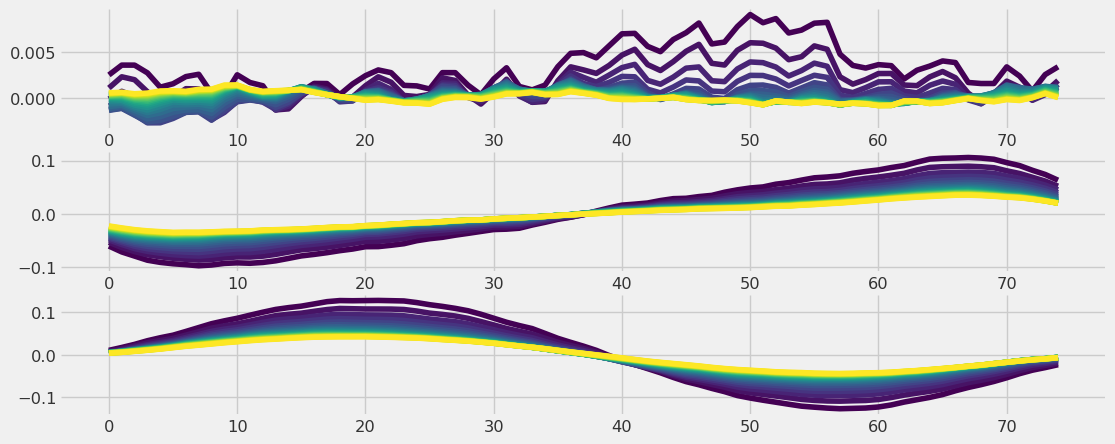

In [14]:
import matplotlib.cm as cm

def plot_iterations(data, iterations):
    """Plot lines with gradient color representing different iterations."""
    colors = cm.viridis(np.linspace(0, 1, iterations))
    fig, ax = plt.subplots(3,1)
    for i in range(iterations):
        # plt.plot(data[i], color=colors[i], label=f'Iteration {i+1}')
        ax[0].plot(data[i][:, 0], color=colors[i])
        ax[1].plot(data[i][:, 1], color=colors[i])
        ax[2].plot(data[i][:, 2], color=colors[i])

    # plt.colorbar(cm.ScalarMappable(cmap='viridis'), label='Iteration')
    plt.legend()
    plt.show()

plot_iterations(trigger_images, len(trigger_images))
plt.show()

In [15]:

def find_minima(data):
    ''' finds minima and returns its value with index'''
    minima = []
    for i in range(1, len(data)-1):
        if data[i] < data[i-1] and data[i] < data[i+1]:
            minima.append((data[i], i))

    ## Last value should always be part of minima
    minima.append((data[-1], len(data)-1))

    return minima

def select_trigger(data, trigger_list):
    minima = find_minima(data)
    minima = sorted(minima, key = lambda x: x[0])

    trigger = None
    for i in minima:
        trigger = trigger_list[i[1]]

        if np.sum(np.abs(trigger)) > 1:
            break

    return trigger

final_trigger = select_trigger(change_rates, trigger_images)


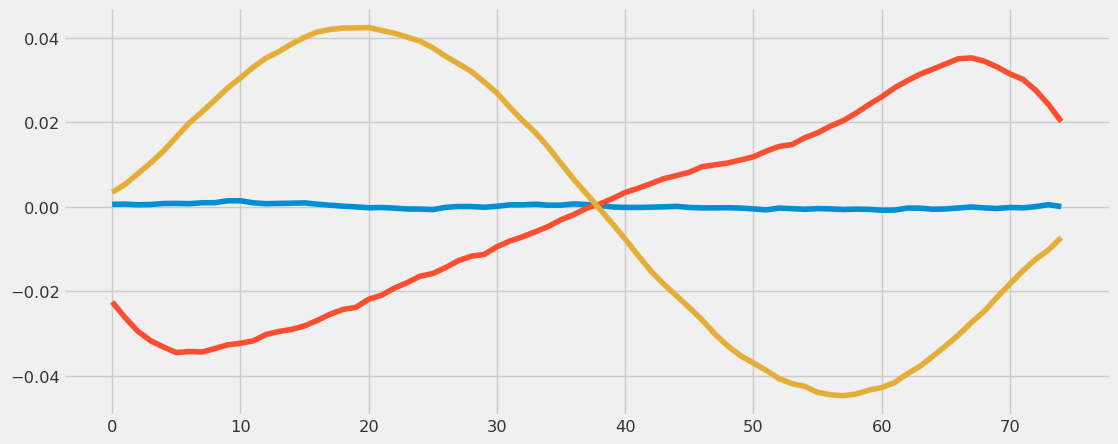

In [16]:
plt.plot(final_trigger)

In [57]:

model1 = load_clean_model(DATA_DIRECTORY_PATH)
model2 = load_poisoned_model(DATA_DIRECTORY_PATH, id = 39)

trigger = np.random.uniform(-0.01, 0.01, (75, 3))

iterations = 50

temperature = np.concatenate([
    np.geomspace(0.05, 0.001, iterations//2),
    np.geomspace(0.001, 0.001, iterations//2)
])

loss3_weight = np.concatenate([
    np.geomspace(0.001, 0.001, 50),
    np.geomspace(10, 10, 50),
    # np.geomspace(10, 10, 25),
])


for iter in range(0, iterations):

    sample = get_sample(CLEAN_DATA)
    trigger_position = random.choice([1,200,324])
    # trigger_position = 1

    ## Generate Delta Triggers
    delta_triggers = []
    dx = temperature[iter]
    for i in range(0, 75*3):
        delta = np.zeros((75, 3))
        delta[i//3, i%3] += dx
        delta_triggers.append(delta)
    for i in range(0, 75*3):
        delta = np.zeros((75, 3))
        delta[i//3, i%3] += -dx
        delta_triggers.append(delta)

    # for i in range(0, 75*3*2):
    #     delta = np.random.uniform(-dx, dx, (75, 3))
    #     delta_triggers.append(delta)

    ## Create timeseries triggers of delta triggers
    trigger_list = [copy.deepcopy(trigger)]
    for i in range(len(delta_triggers)):

        new_trigger = np.clip(trigger + delta_triggers[i], -0.05, 0.05)
        trigger_list.append(new_trigger)

    triggered_samples = [to_timeseries(add_trigger(sample, trig, pos = trigger_position)) for trig in trigger_list]

    ## Load the models
    y_true = model1.predict(n=400,series=triggered_samples,verbose=False)
    y_pred = model2.predict(n=400,series=triggered_samples,verbose=False)

    scores = []
    seperated_scores = []

    for i in tqdm(range(len(trigger_list)), disable=True):

        loss1, loss2, loss3 = loss_function(y_true[i], triggered_samples[i], y_pred[i], pos = trigger_position, length = 75)

        # total loss
        total_loss = loss1 + loss2 + (loss3 * loss3_weight[iter])

        scores.append(
            total_loss
        )

        seperated_scores.append(
            [loss1, loss2, loss3]
        )

    seperated_scores = np.mean(seperated_scores, axis = 0)

    print(f"ITER {iter} | {temperature[iter]} | -- Previous loss: {scores[0]} -- Best MSE loss: {max(scores)} -- mean MSE loss: {np.mean(scores)}")
    print(seperated_scores)

    ## make a new trigger but doing a weighted average using the scores obtained
    new_delta_trigger = np.zeros((75, 3))

    summ = 0
    count = 0
    for i in range(1, len(scores)):
        
        if scores[i] >= scores[0]:
            new_delta_trigger += delta_triggers[i-1] * (scores[i] - scores[0])
            summ += abs(scores[i] - scores[0])
            count += 1

    if count == 0:
        new_delta_trigger = new_delta_trigger
    else:
        new_delta_trigger = (new_delta_trigger * count) / (summ)

    trigger += new_delta_trigger
    trigger = np.clip(trigger, -0.05, 0.05)
    

    # summ = 0
    # for i in range(0, calls):
    #     if scores[i] >= scores[0]:
    #         new_trigger += trigger_list[i] * (scores[i] - scores[0])
    #         summ += np.abs(scores[i] - scores[0])

    # if summ == 0:
    #     new_trigger = trigger
    # else:
    #     new_trigger = new_trigger / (summ)

    ## Select the best trigger
    # new_trigger = trigger_list[scores.index(max(scores))]

    ## add decay to trigger
    # new_trigger -= 0.0003 * np.sign(new_trigger)

    ## Clamp the score to first reach a close representation of this trigger

    # trigger = new_trigger



# y_pred = to_timeseries(sample) + 0.1

# def normalised_timeseries(series):
#     return TimeSeries.from_values(series.values())

# y_true = normalised_timeseries(y_true)
# y_pred = normalised_timeseries(y_pred)

# print("DTW loss: ", MSELossWithDTW(y_true, y_pred))
# print("MSE loss: ", MSELoss(y_true, y_pred))

# %lprun -f time_test -f to_timeseries -f add_trigger time_test()


KeyboardInterrupt: 

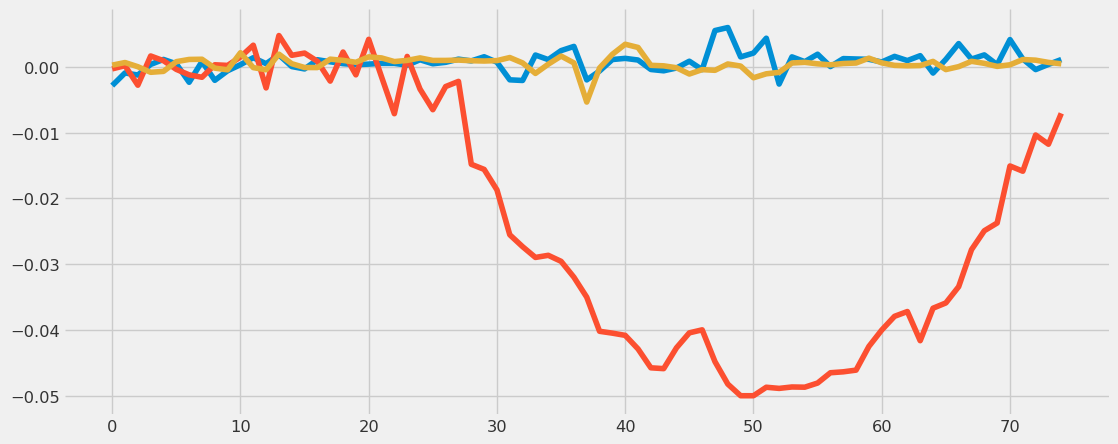

In [15]:
plt.plot(trigger)

<Axes: xlabel='time'>

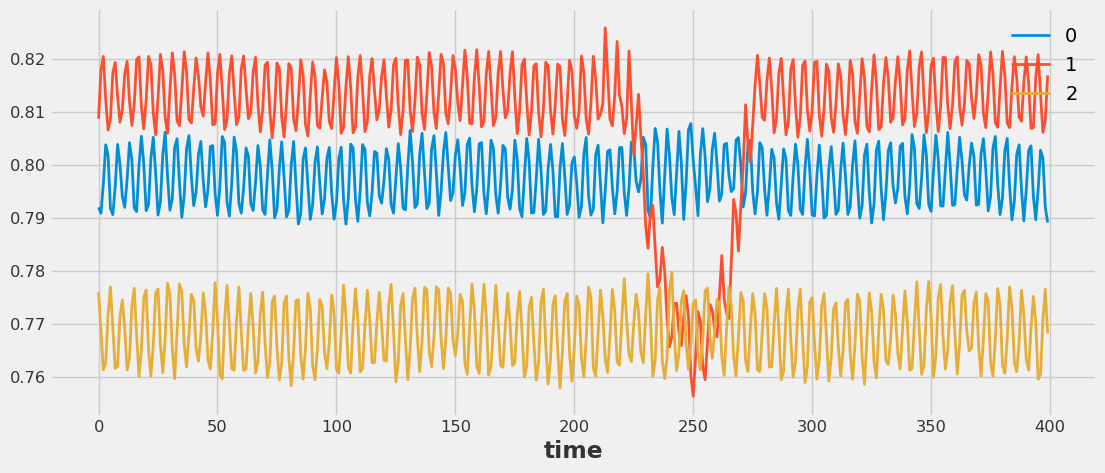

In [16]:
sample = get_sample(CLEAN_DATA)

triggered_sample = to_timeseries(add_trigger(sample, trigger, pos = 200))

triggered_sample.plot()

<Axes: xlabel='time'>

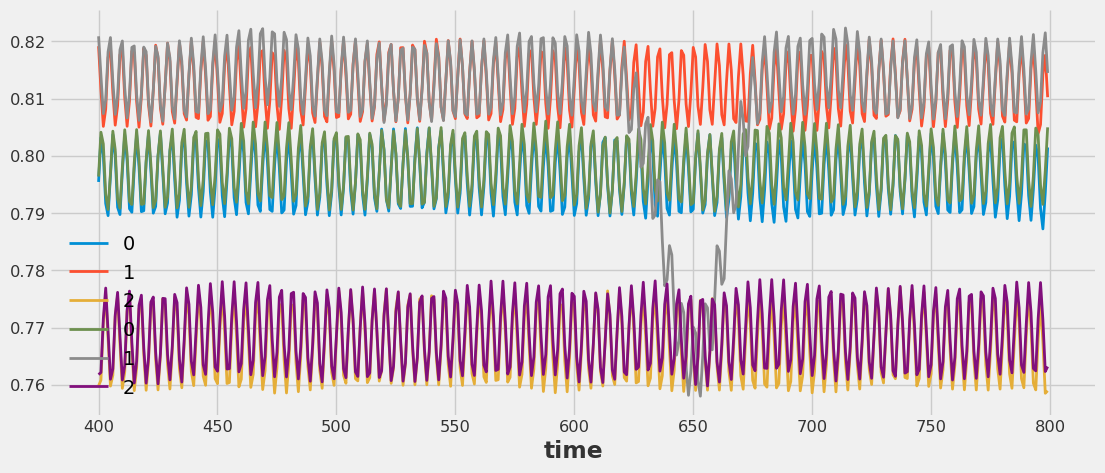

In [17]:
model1.predict(n=400,series=triggered_sample,verbose=False).plot()
model2.predict(n=400,series=triggered_sample,verbose=False).plot()

<Axes: xlabel='time'>

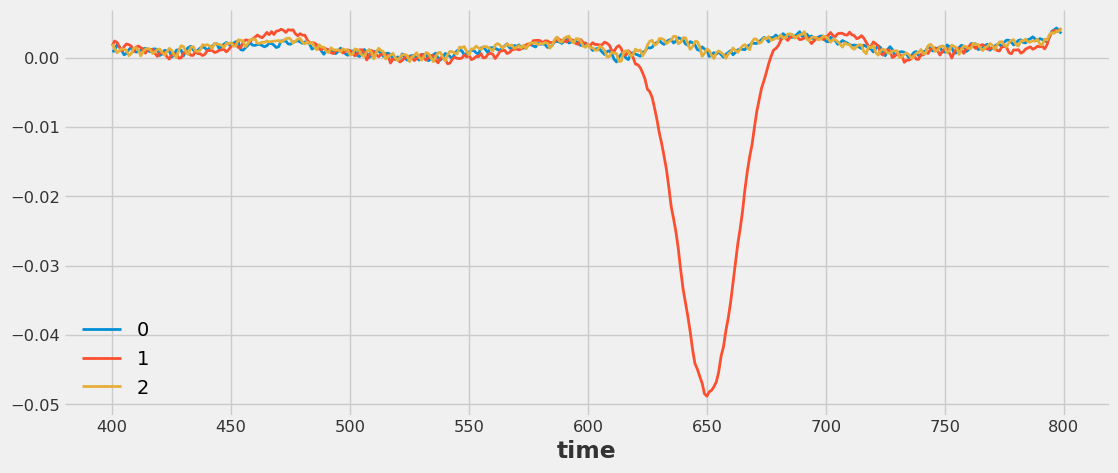

In [18]:
(model2.predict(n=400,series=triggered_sample,verbose=False) - model1.predict(n=400,series=triggered_sample,verbose=False)).plot()

In [9]:
model = load_clean_model(DATA_DIRECTORY_PATH)
sample = get_sample(CLEAN_DATA)

model.predict(n=400,series=to_timeseries(sample),verbose=False)

<TimeSeries (DataArray) (time: 400, component: 3, sample: 1)> Size: 5kB
array([[[0.80012256],
        [0.8053957 ],
        [0.7671973 ]],

       [[0.7921319 ],
        [0.8059036 ],
        [0.77387476]],

       [[0.78837585],
        [0.8134903 ],
        [0.7687986 ]],

       ...,

       [[0.7990809 ],
        [0.81145483],
        [0.7583236 ]],

       [[0.7993662 ],
        [0.8045382 ],
        [0.7657772 ]],

       [[0.7915913 ],
        [0.80466485],
        [0.77256656]]], dtype=float32)
Coordinates:
  * time       (time) int64 3kB 400 401 402 403 404 405 ... 795 796 797 798 799
  * component  (component) object 24B '0' '1' '2'
Dimensions without coordinates: sample
Attributes:
    static_covariates:  None
    hierarchy:          None